In [765]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(style="dark")
plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')

In [766]:
df = pd.read_csv("Raw_data.csv", header = None)
df_rows, df_cols = df.shape
print(f"Dataset shape: {df_rows} rows x {df_cols} cols")
display(df.head())
print("Raw dataset is messy and needs preprocessing.")

Dataset shape: 329 rows x 9 cols


,0,1,2,3,4,5,6,7,8
0,Electrical Engineering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S.No.,Name Of Professor,Designation,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects,NaN,Domain
2,NaN,NaN,NaN,NaN,NaN,NaN,Completed,Ongoing,NaN
3,1,Dr Sharvan Kumar Pahuja,Professor & Head,27,11,5,5,0,signal processing
4,2,Dr Harimurugan,Assistant Professor (Grade-I),12,14,1,1,0,ML


Raw dataset is messy and needs preprocessing.


In [767]:
departments = [
    "Electrical Engineering",
    "Humanities & Management",
    "Electronics & Communication Engineering",
    "BioTechnology",
    "Chemistry",
    "Chemical Engineering",
    "Mechanical Engineering",
    "Physics",
    "Textile Engineering",
    "Civil Engineering",
    "Industrial Production and Engineering",
    "Computer Science and Engineering",
    "Information Technology",
    "Instrumentation and Control Engineering"
]

dept_indices = {}
for i in range(len(df)):
    cell = df.iat[i,0]
    if isinstance(cell, str):
        cell_str = cell.strip()
        for dept in departments:
            if cell_str.lower() == dept.lower():
                dept_indices[dept] = i

print("\nDetected department start rows:")
for dept in departments:
    print(f"{dept} : {dept_indices.get(dept, 'NOT FOUND')}")


Detected department start rows:
Electrical Engineering : 0
Humanities & Management : 16
Electronics & Communication Engineering : 33
BioTechnology : 68
Chemistry : 84
Chemical Engineering : 102
Mechanical Engineering : 125
Physics : 155
Textile Engineering : 173
Civil Engineering : 195
Industrial Production and Engineering : 221
Computer Science and Engineering : 243
Information Technology : 280
Instrumentation and Control Engineering : 308


In [768]:
slices = []
for dept in departments:
    if dept not in dept_indices:
        continue
    start = dept_indices[dept] + 1
    next_starts = [dept_indices[d] for d in departments if d in dept_indices and dept_indices[d] > dept_indices[dept]]
    end = min(next_starts) - 1 if next_starts else df_rows - 1
    slices.append((dept, start, end))

print("\nDepartment table slices:")
for s in slices:
    print(s)


Department table slices:
('Electrical Engineering', 1, 15)
('Humanities & Management', 17, 32)
('Electronics & Communication Engineering', 34, 67)
('BioTechnology', 69, 83)
('Chemistry', 85, 101)
('Chemical Engineering', 103, 124)
('Mechanical Engineering', 126, 154)
('Physics', 156, 172)
('Textile Engineering', 174, 194)
('Civil Engineering', 196, 220)
('Industrial Production and Engineering', 222, 242)
('Computer Science and Engineering', 244, 279)
('Information Technology', 281, 307)
('Instrumentation and Control Engineering', 309, 328)


In [769]:
col_mapping = {
    0: "S.No.",
    1: "Name",
    2: "Designation",
    3: "No. of Journal Publications",
    4: "No. of Conference Publications",
    5: "Book/Chapter",
    6: "Research Projects - Completed",
    7: "Research Projects - Ongoing",
    8: "Domain"
}
cleaned_parts = []

In [770]:
for dept, header_row, end_row in slices:
    block = df.iloc[header_row:end_row+1].copy().reset_index(drop=True)

    # Make sure block has 9 columns
    block.columns = list(range(block.shape[1]))
    if block.shape[1] >= 9:
        block = block.iloc[:, :9]
    else:
        for c in range(block.shape[1], 9):
            block[c] = pd.NA
        block = block[[i for i in range(9)]]

    block = block.rename(columns=col_mapping)

    # Remove internal header rows (S.No, Name, etc)
    def is_header_row(r):
        name_val = r["Name"]
        s_no = r["S.No."]
        if isinstance(name_val, str) and ("name" in name_val.lower() or "professor" in name_val.lower()):
            return True
        if isinstance(s_no, str) and "s.no" in s_no.lower():
            return True
        return False

    block = block[~block.apply(is_header_row, axis=1)]

    # Remove blank rows
    block = block[block["Name"].notna()]

    # Clean text fields
    for c in ["Name", "Designation", "Domain"]:
        block[c] = block[c].astype(str).str.strip().replace({"nan": pd.NA})

    # Convert numeric fields
    numeric_cols = [
        "No. of Journal Publications",
        "No. of Conference Publications",
        "Book/Chapter",
        "Research Projects - Completed",
        "Research Projects - Ongoing"
    ]

    for nc in numeric_cols:
        block[nc] = pd.to_numeric(block[nc], errors="coerce").fillna(0).astype(int)

    # Add Department
    block["Department"] = dept

    cleaned_parts.append(block.reset_index(drop=True))

In [771]:
clean_df = pd.concat(cleaned_parts, ignore_index=True)

# STEP 6 - Clean Name/Domain field
clean_df["Name"] = clean_df["Name"].fillna("").str.strip()
clean_df["Domain"] = clean_df["Domain"].fillna("Not Provided").str.strip()
display(clean_df.sample(5))

,S.No.,Name,Designation,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects - Completed,Research Projects - Ongoing,Domain,Department
170,4,Dr Vishal Santosh Sharma,Professor,74,5,8,0,0,"3D printing, Machining,",Industrial Production and Engineering
213,30,Dr Shveta Mahajan,Assistant Professor (Grade-II),3,19,1,1,2,ML,Computer Science and Engineering
115,24,Dr Ravi Kant Ravi,Assistant Professor (Grade-II),14,6,4,0,3,Solar Thermal Systems,Mechanical Engineering
218,2,Dr Kusum Bharti,Assistant Professor (Grade-I),18,11,2,1,1,Machine Learning,Information Technology
119,3,Dr Rohit Mehra,Professor,215,8,8,6,1,Nanotechnology,Physics


In [772]:
clean_df["Total Publications"] = (
    clean_df["No. of Journal Publications"]
    + clean_df["No. of Conference Publications"]
    + clean_df["Book/Chapter"]
)
first = clean_df[["S.No.","Name","Designation", "Department", "Domain"]]
rest = clean_df.drop(columns=["S.No.","Name","Designation","Department", "Domain"])
clean_df = pd.concat([first, rest], axis=1)

In [773]:
clean_df.to_csv("cleaned_data.csv", index=False)
print("\nCleaning finished!")
print("Final shape:", clean_df.shape)
print("\nPreview:")
display(clean_df.sample(5))


Cleaning finished!
Final shape: (253, 11)

Preview:


,S.No.,Name,Designation,Department,Domain,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects - Completed,Research Projects - Ongoing,Total Publications
221,5,Dr Ranjeet Kumar Rout,Assistant Professor (Grade-I),Information Technology,Deep Learning,59,21,4,1,2,84
169,3,Dr Anish Kumar Sachdeva,Professor,Industrial Production and Engineering,Supply Chain Management,119,62,23,0,3,204
87,14,Dr Deepak Sahu,Assistant Professor (Grade-I),Chemical Engineering,Chemical Process Safety,14,20,8,2,2,42
98,7,Mr. Ajay Trehan,Associate Professor,Mechanical Engineering,Renewable Energy,1,3,2,1,0,6
13,3,Dr Aditya Prakash,Associate Professor & Head,Humanities & Management,literature,10,0,0,0,0,10


In [774]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   S.No.                           253 non-null    object
 1   Name                            253 non-null    object
 2   Designation                     253 non-null    object
 3   Department                      253 non-null    object
 4   Domain                          253 non-null    object
 5   No. of Journal Publications     253 non-null    int64 
 6   No. of Conference Publications  253 non-null    int64 
 7   Book/Chapter                    253 non-null    int64 
 8   Research Projects - Completed   253 non-null    int64 
 9   Research Projects - Ongoing     253 non-null    int64 
 10  Total Publications              253 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 21.9+ KB


In [775]:
print("Total unique domain values:", clean_df["Domain"].nunique())
print("\nUnique Domain values:")
for val in clean_df["Domain"].unique():
    print(repr(val))

Total unique domain values: 142

Unique Domain values:
'signal processing'
'ML'
'Power system'
'Power System'
'micro grid'
'Robotics'
'Electrostatics'
'HR'
'Financal economics'
'literature'
'consumer behavaour'
'Financal econimics'
'0'
'Financial economics'
'Communication Systems'
'Human-Computer Interaction (HCI)'
'Signal processing'
'Nanoelectronics'
'iot'
'Antenna design'
'Signal Processing'
'Spectrum'
'Amplifier'
'Semi conductors'
'Bioprocess'
'Microbiology'
'Biomaterials'
'Waste water managenment'
'Nanotechnology'
'Organic synthesis'
'Inorganic synthesis'
'Ionic Liquid'
'Waste Water Treatment'
'Computational Fluid Dynamics'
'Renewable Energy'
'Hydrogen Energy'
'Chemical Process Safety'
'Environmental Engineering'
'Welding Technology'
'Mechatronics'
'Structure Property correlation'
'Turbulent Flows'
'Vibration Engineering'
'Surface Textures'
'Product Design and Innovation'
'Fluid Machinery'
'Non-Newtonian Rheologies of lubricants'
'Solar Thermal Systems'
'Thermal Engineering'
'Lase

In [776]:
import pandas as pd
import re
from collections import Counter

# --- normalizer & splitter (same as before) ---
def normalize(s):
    if not isinstance(s, str):
        return ""
    s = s.lstrip("\ufeff").strip()
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1]
    s = re.sub(r"[·•]", " ", s)
    s = re.sub(r"[\[\]\(\)\/\|]", ",", s)
    s = re.sub(r"\s*&\s*", ",", s)
    s = re.sub(r"\s+,\s+", ",", s)
    s = re.sub(r"\s+", " ", s)
    s = s.strip().strip(".,;:-")
    return s.lower()

def split_tokens(cell):
    s = normalize(cell)
    if s in ("", "nan", "not provided", "0"):
        return []
    parts = re.split(r"[,;]+", s)
    return [p.strip() for p in parts if p.strip()]

# --- base primary_map (keeps your previous good mappings) ---
# (You can paste your full primary_map here; for brevity assume we start from the
#  dictionary used earlier and only extend it below.)
primary_map = {
    # --- AI & ML ---
    "ml": "machine learning",
    "machine learning": "machine learning",
    "deep learning": "deep learning",
    "dl": "deep learning",
    "ai": "artificial intelligence",
    "data mining": "data mining",
    "data analytics": "data analytics",
    "nlp": "natural language processing",
    "natural language processing": "natural language processing",
    "digital image processing": "digital image processing",
    "computer vision": "computer vision",
    "time series diagnostics": "time series analysis",

    # --- Networking ---
    "computer networks": "computer networks",
    "computer network": "computer networks",
    "networking and communication": "computer networks",
    "wireless sensor networks": "wireless sensor networks",
    "wireless sensor network": "wireless sensor networks",
    "wireless networks": "wireless networks",
    "wireless communication systems": "communication systems",
    "communication systems": "communication systems",
    "spectrum": "communication systems",
    "cloud computing": "cloud computing",
    "virtual private network": "network security",
    "vpn": "network security",
    "iot": "internet of things",

    # --- Signal & Control ---
    "signal processing": "signal processing",
    "control systems": "control systems",
    "control system": "control systems",
    "control theory and applications": "control systems",
    "controller design": "control systems",
    "inverted pendulum system": "control systems",
    "autonomous mobile robot": "robotics",
    "brain-computer interface": "brain-computer interface",
    "bci": "brain-computer interface",
    "electrical measurements and instrumentation": "instrumentation & control",
    "low temperature instrumentation": "instrumentation & control",

    # --- Electronics / Physics ---
    "nanoelectronics": "nanoelectronics",
    "semiconductors": "semiconductors",
    "semi conductors": "semiconductors",
    "amplifier": "analog electronics",
    "antenna design": "antenna design",
    "nuclear astrophysics": "nuclear astrophysics",
    "remote sensing": "remote sensing",

    # --- Power & Energy ---
    "power system": "power systems",
    "power systems": "power systems",
    "microgrid": "microgrid",
    "micro grid": "microgrid",
    "renewable energy": "renewable energy",
    "hydrogen energy": "hydrogen energy",
    "solar thermal systems": "solar thermal systems",
    "thermal engineering": "thermal engineering",

    # --- Mechanical / Manufacturing ---
    "machining": "manufacturing",
    "manufacturing": "manufacturing",
    "additive manufacturing": "additive manufacturing",
    "3d printing": "additive manufacturing",
    "welding": "welding",
    "welding technology": "welding",
    "tribology": "tribology",
    "surface textures": "surface engineering",
    "surface engineering": "surface engineering",
    "fluid machinery": "fluid machinery",
    "vibration engineering": "vibration engineering",
    "product design and innovation": "product design",
    "non-newtonian rheologies of lubricants": "materials science",
    "manufacturing of composites": "composite manufacturing",
    "multiaxial fatigue life prediction of weldments": "materials fatigue & failure",
    "stress corrosion cracking": "materials corrosion",

    # --- Civil / Environmental ---
    "environmental engineering": "environmental engineering",
    "water and wastewater": "water and wastewater",
    "waste water treatment": "water and wastewater",
    "waste water management": "water and wastewater",
    "transportation engineering": "transportation engineering",
    "turbulent fluvial flows": "environmental fluid dynamics",
    "geotechnical engineering": "geotechnical engineering",
    "geotechnical and geoenvironmental engineering": "geotechnical engineering",
    "structure property correlation": "materials science",
    "bridge engineering": "structural engineering",

    # --- Chemical / Materials ---
    "chemical process safety": "chemical engineering",
    "chemical engineering": "chemical engineering",
    "nanotechnology": "nanotechnology",
    "material science": "materials science",
    "materials": "materials science",
    "organic synthesis": "organic chemistry",
    "inorganic synthesis": "inorganic chemistry",

    # --- Bio / Medical ---
    "bioprocess": "bioprocess engineering",
    "microbiology": "microbiology",
    "biomaterials": "biomaterials",
    "biomedical instrumentation": "biomedical instrumentation",

    # --- Textiles ---
    "garment design": "garment design",

    # --- Management ---
    "management marketing": "management and marketing",
    "supply chain management": "supply chain management",
    "productivity improvement and advanced manufacturing": "operations & manufacturing",

    # fallback
    "other": "other"
}


# --- ADD/OVERRIDE mappings for the newly-unmapped tokens you posted ---
extra_map = {
    # humanities / management / misc
    "literature": "literature",
    "hr": "human resources",
    "financal economics": "financial economics",
    "financal econimics": "financial economics",
    "financial economics": "financial economics",
    "consumer behavaour": "consumer behaviour",
    "management marketing": "management and marketing",
    "operations management": "operations management",
    "engineering management": "engineering management",
    "engineering economics": "engineering economics",
    "productivity improvement and advanced manufacturing": "operations & manufacturing",

    # mechanical / manufacturing / materials
    "machining": "manufacturing",
    "traditional machining": "manufacturing",
    "tribology": "tribology",
    "vibration engineering": "vibration engineering",
    "surface engineering": "surface engineering",
    "surface textures": "surface engineering",
    "product design and innovation": "product design",
    "fluid machinery": "fluid machinery",
    "non-newtonian rheologies of lubricants": "materials science",
    "multiaxial fatigue life prediction of weldments": "materials fatigue & failure",
    "stress corrosion cracking": "materials corrosion",
    "manufacturing of composites": "composite manufacturing",
    "mechatronics": "mechatronics",

    # civil / structural / geo
    "structural engineering": "structural engineering",
    "structure property correlation": "materials science",
    "turbulent flows": "turbulent flows",
    "turbulent fluvial flows": "environmental fluid dynamics",
    "transportation engineering": "transportation engineering",
    "geotechnical and geoenvironmental engineering": "geotechnical engineering",
    "earth retaining structures": "geotechnical engineering",
    "experimental rock mechanics": "rock mechanics",
    "highway materials": "highway materials",
    "durability evaluation of different concretes": "concrete technology",
    "durability behavior of concrete composites": "concrete technology",
    "durability study of concrete under aggressive environment": "concrete technology",
    "bridge engineering": "structural engineering",

    # civil-related broader heuristics already present will pick these up; explicit adds help

    # chemical / materials / physics
    "ionic liquid": "chemical engineering",
    "laser-plasma accelerators": "laser-plasma accelerators",
    "multiferroics": "multiferroics",
    "detector development": "detector development",
    "electrostatics": "electrostatics",
    "condensed matter physics": "condensed matter physics",
    "theoretical high energy physics": "high energy physics",
    "theoretical nuclear physics": "nuclear physics",
    "nuclear astrophysics": "nuclear astrophysics",
    "computational fluid dynamics": "computational fluid dynamics",

    # AI / ML / data
    "natural language processing": "natural language processing",
    "data mining": "data mining",
    "data analytics": "data analytics",
    "digital image processing": "digital image processing",
    "computer vision": "computer vision",
    "time series diagnostics": "time series analysis",
    "probabilistic data structures": "data structures",
    "scheduling theory": "scheduling theory",
    "optimization": "optimization",
    "blockchain": "blockchain",

    # networking & sensors
    "wireless personal area": "wireless networks",
    "spectrum": "communication systems",
    "wireless communication systems": "communication systems",
    "virtual private network": "network security",
    "iot": "internet of things",
    "robotics": "robotics",
    "autonomous mobile robot": "robotics",
    "inverted pendulum system": "control systems",
    "intelligent": "control systems",
    "nonlinear control": "control systems",
    "advances in control theory": "control systems",
    "controller design": "control systems",
    "electrical measurements and instrumentation": "instrumentation & control",
    "low temperature instrumentation": "instrumentation & control",
    "biointsrumentation": "biomedical instrumentation",
    "biomedical instrumentation": "biomedical instrumentation",
    "brain-computer interface": "brain-computer interface",
    "bci": "brain-computer interface",

    #remaining
    "life cycle assessment": "life cycle assessment",
    "human-computer interaction": "human-computer interaction",
    "hci": "human-computer interaction",
    "soil-structure interaction": "soil-structure interaction",
    "concrete structures": "concrete technology",
    "geopolymer concrete": "concrete technology",
    "environmental fluid dynamics": "environmental fluid dynamics",
    "operating system design": "operating system design"
}

# merge extra_map into primary_map (override or set)
primary_map.update(extra_map)

# --- category map (keep your previous categories; add any missing categories) ---
category_map = {
    "machine learning": "AI & ML",
    "deep learning": "AI & ML",
    "artificial intelligence": "AI & ML",
    "data mining": "AI & ML",
    "data analytics": "AI & ML",
    "natural language processing": "AI & ML",
    "computer vision": "AI & ML",
    "digital image processing": "AI & ML",
    "time series analysis": "AI & ML",

    "computer networks": "Networking & Communications",
    "communication systems": "Networking & Communications",
    "network security": "Networking & Communications",
    "internet of things": "Networking & Communications",
    "cloud computing": "Networking & Communications",

    "signal processing": "Signal Processing & Control",
    "control systems": "Signal Processing & Control",
    "instrumentation & control": "Signal Processing & Control",
    "brain-computer interface": "Signal Processing & Control",

    "nanoelectronics": "Electronics",
    "semiconductors": "Electronics",
    "analog electronics": "Electronics",

    "power systems": "Power & Energy",
    "microgrid": "Power & Energy",
    "renewable energy": "Power & Energy",

    "mechatronics": "Mechanical & Mechatronics",
    "manufacturing": "Mechanical & Manufacturing",
    "additive manufacturing": "Mechanical & Manufacturing",
    "welding": "Mechanical & Manufacturing",
    "composite manufacturing": "Mechanical & Manufacturing",

    "geotechnical engineering": "Civil & Environmental",
    "structural engineering": "Civil & Environmental",
    "concrete technology": "Civil & Environmental",
    "water and wastewater": "Civil & Environmental",
    "transportation engineering": "Civil & Environmental",
    "rock mechanics": "Civil & Environmental",

    "chemical engineering": "Chemical & Materials",
    "organic chemistry": "Chemical & Materials",
    "inorganic chemistry": "Chemical & Materials",
    "materials science": "Chemical & Materials",
    "nanotechnology": "Chemical & Materials",

    "bioprocess engineering": "Biotech & Life Sciences",
    "microbiology": "Biotech & Life Sciences",
    "biomaterials": "Biotech & Life Sciences",
    "biomedical instrumentation": "Biotech & Life Sciences",

    "textile manufacturing": "Textiles",
    "technical textiles": "Textiles",
    "healthcare textiles": "Textiles",

    "supply chain management": "Management & Humanities",
    "operations management": "Management & Humanities",
    "management and marketing": "Management & Humanities",
    "financial economics": "Management & Humanities",
    "engineering management": "Management & Humanities",
    "engineering economics": "Management & Humanities",
    "life cycle assessment": "Sustainability",

    "operating system design": "Computer Systems",
    "data structures": "Computer Systems",
    "scheduling theory": "Computer Systems",
    "optimization": "Theory & Optimization",
    "blockchain": "Distributed Systems",

    "high energy physics": "Physics",
    "nuclear physics": "Physics",
    "condensed matter physics": "Physics",
    "detector development": "Physics",
    "laser-plasma accelerators": "Physics",

    "robotics": "Robotics & Automation",
    "control systems": "Signal Processing & Control",
    "other": "Other"
}


In [777]:
# --- mapping routine ---
unmapped = Counter()
primary_vals = []
all_domains = []
categories = []

for cell in clean_df['Domain'].fillna("").astype(str):
    tokens = split_tokens(cell)
    mapped = []
    for t in tokens:
        t_norm = t.strip().lower()
        # direct map
        if t_norm in primary_map:
            p = primary_map[t_norm]
        else:
            # heuristics (some common patterns)
            if "machine" in t_norm and "learn" in t_norm:
                p = "machine learning"
            elif "deep" in t_norm and "learn" in t_norm:
                p = "deep learning"
            elif "signal" in t_norm and "process" in t_norm:
                p = "signal processing"
            elif "power" in t_norm:
                p = "power systems"
            elif "microgrid" in t_norm or "micro grid" in t_norm:
                p = "microgrid"
            elif "textile" in t_norm or "yarn" in t_norm or "fibre" in t_norm or "fiber" in t_norm:
                p = "textile manufacturing"
            elif "waste" in t_norm or "water" in t_norm:
                p = "water and wastewater"
            elif "bio" in t_norm and ("process" in t_norm or "micro" in t_norm or "material" in t_norm):
                p = "bioprocess engineering" if "bioprocess" in t_norm else "biomaterials"
            else:
                unmapped[t_norm] += 1
                p = "other"
        mapped.append(p)
    if not mapped:
        mapped = ["other"]
    primary_choice = mapped[0]
    category = category_map.get(primary_choice, "Other")
    primary_vals.append(primary_choice)
    all_domains.append(mapped)
    categories.append(category)

# attach and save
clean_df['All_Domains'] = all_domains
clean_df['Primary Domain'] = primary_vals
clean_df['Domain Category'] = categories
clean_df['Primary Domain'] = clean_df['Primary Domain'].fillna("other").replace({"": "other"})
clean_df['Domain Category'] = clean_df['Domain Category'].fillna("Other").replace({"": "Other"})

# --- report ---
print("\nNew Domain Category counts:")
print(clean_df['Domain Category'].value_counts().sort_values(ascending=False))
print("\nNew Primary Domain (top 30):")
print(clean_df['Primary Domain'].value_counts().head(30))
print("\nRemaining unmapped tokens (distinct):", len(unmapped))
for tok, cnt in unmapped.most_common():
    print(f"{tok!r}: {cnt}")


New Domain Category counts:
Domain Category
Other                          46
AI & ML                        44
Civil & Environmental          29
Chemical & Materials           27
Signal Processing & Control    16
Power & Energy                 16
Networking & Communications    15
Textiles                       13
Biotech & Life Sciences        10
Management & Humanities         9
Mechanical & Manufacturing      7
Physics                         7
Electronics                     5
Robotics & Automation           2
Sustainability                  2
Computer Systems                2
Mechanical & Mechatronics       1
Theory & Optimization           1
Distributed Systems             1
Name: count, dtype: int64

New Primary Domain (top 30):
Primary Domain
machine learning                27
nanotechnology                  15
water and wastewater            14
textile manufacturing           13
renewable energy                10
signal processing                7
other                       

In [778]:
display(clean_df["Domain Category"].value_counts())
display(clean_df["Primary Domain"].value_counts().head(40))

Domain Category
Other                          46
AI & ML                        44
Civil & Environmental          29
Chemical & Materials           27
Signal Processing & Control    16
Power & Energy                 16
Networking & Communications    15
Textiles                       13
Biotech & Life Sciences        10
Management & Humanities         9
Mechanical & Manufacturing      7
Physics                         7
Electronics                     5
Robotics & Automation           2
Sustainability                  2
Computer Systems                2
Mechanical & Mechatronics       1
Theory & Optimization           1
Distributed Systems             1
Name: count, dtype: int64

Primary Domain
machine learning                27
nanotechnology                  15
water and wastewater            14
textile manufacturing           13
renewable energy                10
signal processing                7
other                            7
control systems                  6
artificial intelligence          6
communication systems            5
concrete technology              5
geotechnical engineering         5
computer networks                4
chemical engineering             4
power systems                    4
bioprocess engineering           4
organic chemistry                3
microbiology                     3
internet of things               3
nanoelectronics                  3
financial economics              3
antenna design                   3
literature                       3
structural engineering           3
additive manufacturing           3
materials science                3
supply chain management          3
deep learning                    3
compu

In [779]:
print("\n=== FINAL DATAFRAME ===")
clean_df.sample(5)


=== FINAL DATAFRAME ===


,S.No.,Name,Designation,Department,Domain,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects - Completed,Research Projects - Ongoing,Total Publications,All_Domains,Primary Domain,Domain Category
129,13,Dr Shubhchintak,Assistant Professor Grade-II,Physics,Nuclear astrophysics,28,0,0,0,0,28,[nuclear astrophysics],nuclear astrophysics,Other
69,9,Dr Vickram Jeet Singh,Associate Professor,Chemistry,Ionic Liquid,51,0,5,1,1,56,[chemical engineering],chemical engineering,Chemical & Materials
95,4,Dr Raman Bedi,Professor,Mechanical Engineering,Structure Property correlation,63,30,7,0,2,100,[materials science],materials science,Chemical & Materials
171,5,Dr Ajay Gupta,Associate Professor,Industrial Production and Engineering,Management Marketing,56,34,7,0,1,97,[management and marketing],management and marketing,Management & Humanities
11,1,Dr S J S Bedi,Professor,Humanities & Management,HR,15,2,1,3,0,18,[human resources],human resources,Other


In [780]:
print("=== BASIC INFO ===")
print(clean_df.info())

print("\n=== COLUMN-WISE MISSING VALUES ===")
print(clean_df.isnull().sum())

print("\n=== UNIQUE COUNTS FOR CATEGORICAL COLUMNS ===")
cat_cols = ["Department", "Designation", "Domain Category", "Primary Domain"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(clean_df[col].value_counts())

print("\n=== SHAPE OF DATAFRAME ===")
print(clean_df.shape)

print("\n=== SUMMARY OF NUMERIC COLUMNS ===")
display(clean_df.describe())


=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   S.No.                           253 non-null    object
 1   Name                            253 non-null    object
 2   Designation                     253 non-null    object
 3   Department                      253 non-null    object
 4   Domain                          253 non-null    object
 5   No. of Journal Publications     253 non-null    int64 
 6   No. of Conference Publications  253 non-null    int64 
 7   Book/Chapter                    253 non-null    int64 
 8   Research Projects - Completed   253 non-null    int64 
 9   Research Projects - Ongoing     253 non-null    int64 
 10  Total Publications              253 non-null    int64 
 11  All_Domains                     253 non-null    object
 12  Primary Domain                 

,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects - Completed,Research Projects - Ongoing,Total Publications
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,34.972332,19.667984,5.782609,1.478261,1.007905,60.422925
std,41.959486,24.739926,7.567433,2.520653,1.535279,61.067545
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,5.000000,1.000000,0.000000,0.000000,21.000000
50%,22.000000,12.000000,4.000000,1.000000,0.000000,43.000000
75%,47.000000,24.000000,8.000000,2.000000,1.000000,79.000000
max,347.000000,230.000000,64.000000,19.000000,10.000000,465.000000


In [781]:
clean_df["Total_Projects"] = (clean_df["Research Projects - Completed"] + clean_df["Research Projects - Ongoing"])
clean_df["Has_Projects"] = clean_df["Total_Projects"] > 0
display(clean_df.info())
display(clean_df.head())
clean_df.to_csv("final_cleaned_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   S.No.                           253 non-null    object
 1   Name                            253 non-null    object
 2   Designation                     253 non-null    object
 3   Department                      253 non-null    object
 4   Domain                          253 non-null    object
 5   No. of Journal Publications     253 non-null    int64 
 6   No. of Conference Publications  253 non-null    int64 
 7   Book/Chapter                    253 non-null    int64 
 8   Research Projects - Completed   253 non-null    int64 
 9   Research Projects - Ongoing     253 non-null    int64 
 10  Total Publications              253 non-null    int64 
 11  All_Domains                     253 non-null    object
 12  Primary Domain                  253 non-null    ob

None

,S.No.,Name,Designation,Department,Domain,No. of Journal Publications,No. of Conference Publications,Book/Chapter,Research Projects - Completed,Research Projects - Ongoing,Total Publications,All_Domains,Primary Domain,Domain Category,Total_Projects,Has_Projects
0,1,Dr Sharvan Kumar Pahuja,Professor & Head,Electrical Engineering,signal processing,27,11,5,5,0,43,[signal processing],signal processing,Signal Processing & Control,5,True
1,2,Dr Harimurugan,Assistant Professor (Grade-I),Electrical Engineering,ML,12,14,1,1,0,27,[machine learning],machine learning,AI & ML,1,True
2,3,Dr Kailash Chand Sharma,Assistant Professor (Grade-I),Electrical Engineering,ML,23,24,1,0,0,48,[machine learning],machine learning,AI & ML,0,False
3,4,Dr. Mahesh Kumar,Assistant Professor (Grade-I),Electrical Engineering,Power system,10,13,4,0,0,27,[power systems],power systems,Power & Energy,0,False
4,5,Dr Arun Rathore,Assistant Professor Garde-II,Electrical Engineering,Power System,15,14,1,0,0,30,[power systems],power systems,Power & Energy,0,False


# EDA Starts

### Overall analysis (Homepage)

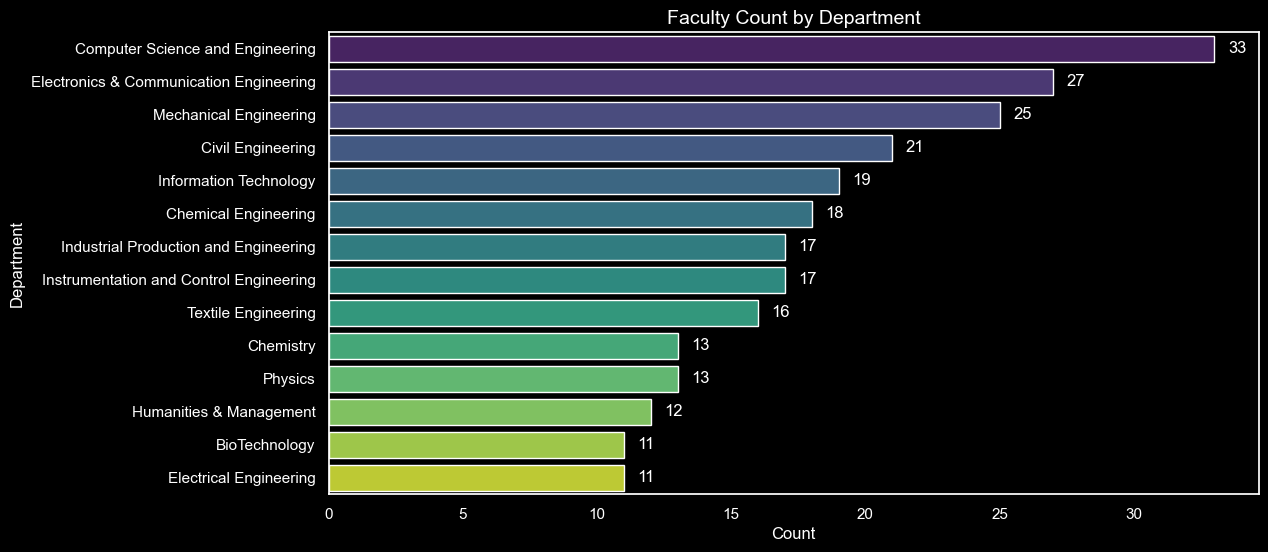

In [782]:
plt.figure(figsize=(12,6))
counts = clean_df["Department"].value_counts()

sns.barplot(x=counts.values, y=counts.index, palette="viridis")
for i, v in enumerate(counts.values):
    plt.text(v + 0.5, i, str(v), va="center")

plt.title("Faculty Count by Department")
plt.xlabel("Count")
plt.ylabel("Department")
plt.show()


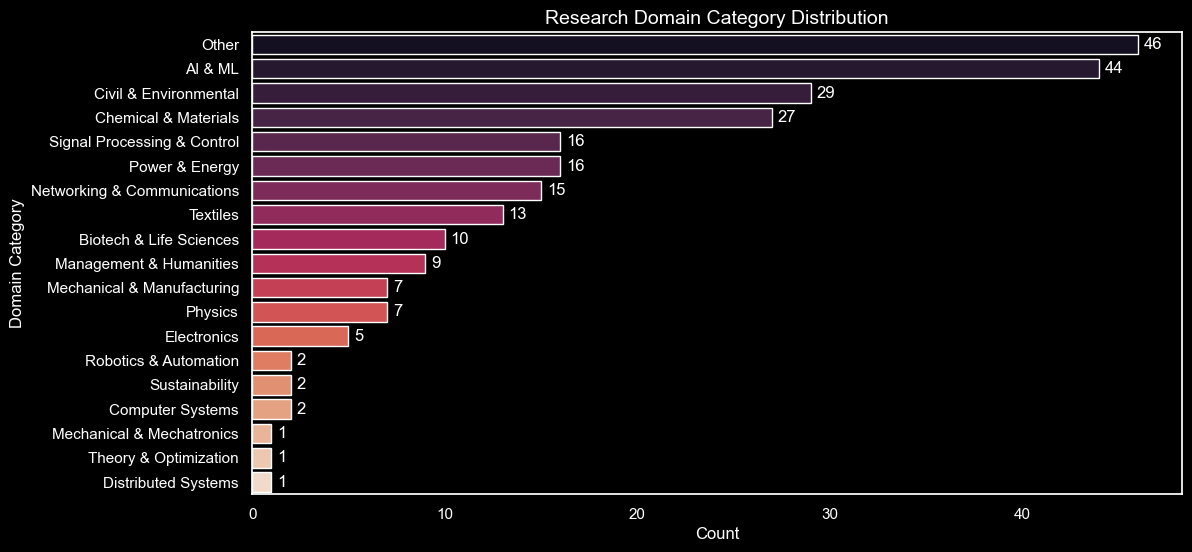

In [783]:
plt.figure(figsize=(12,6))
counts = clean_df["Domain Category"].value_counts()

sns.barplot(x=counts.values, y=counts.index, palette="rocket")
for i, v in enumerate(counts.values):
    plt.text(v + 0.3, i, str(v), va="center")

plt.title("Research Domain Category Distribution")
plt.xlabel("Count")
plt.ylabel("Domain Category")
plt.show()


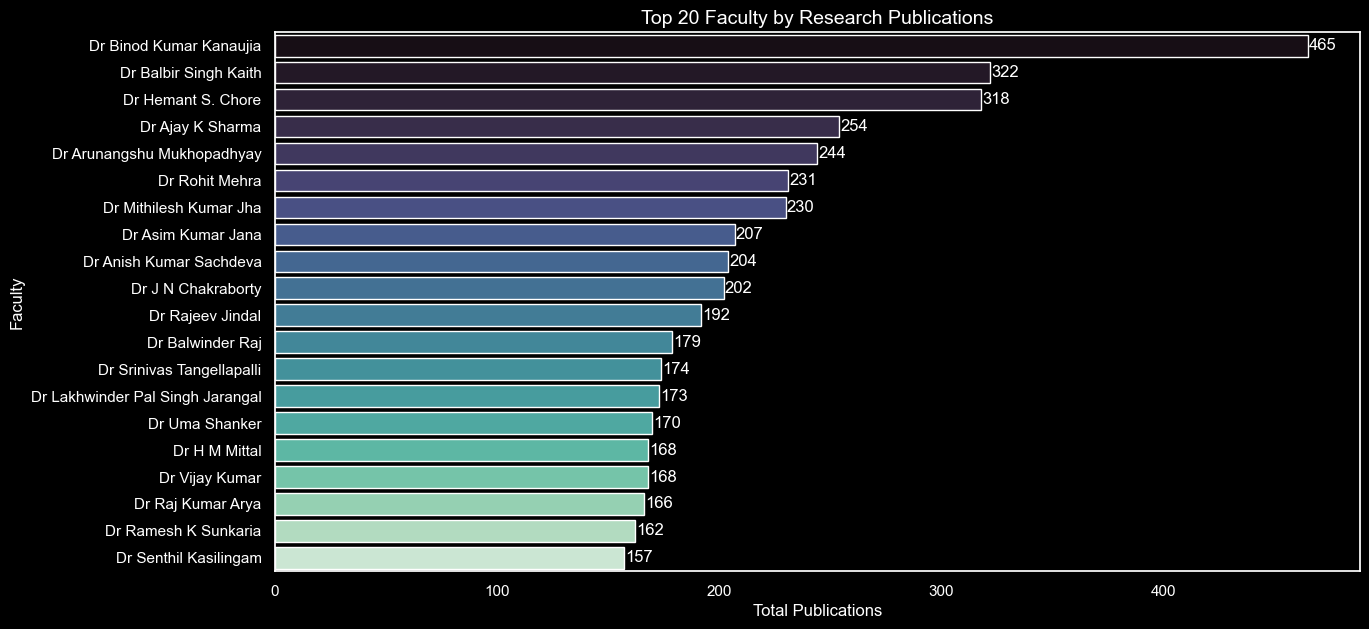

In [ ]:
top20 = clean_df.sort_values("Total Publications", ascending=False).head(20)

plt.figure(figsize=(14,7))
sns.barplot(data=top20, x="Total Publications", y="Name", palette="mako")

for i, v in enumerate(top20["Total Publications"]):
    plt.text(v + 0.5, i, str(v), va="center")

plt.title("Top 20 Faculty by Research Publications")
plt.xlabel("Total Publications")
plt.ylabel("Faculty")
plt.show()


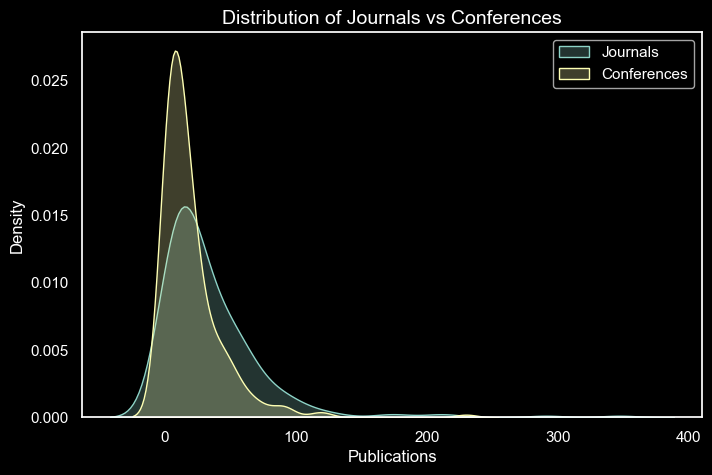

In [785]:
plt.figure(figsize=(8,5))
sns.kdeplot(clean_df["No. of Journal Publications"], shade=True, label="Journals")
sns.kdeplot(clean_df["No. of Conference Publications"], shade=True, label="Conferences")
plt.title("Distribution of Journals vs Conferences")
plt.xlabel("Publications")
plt.legend()
plt.show()


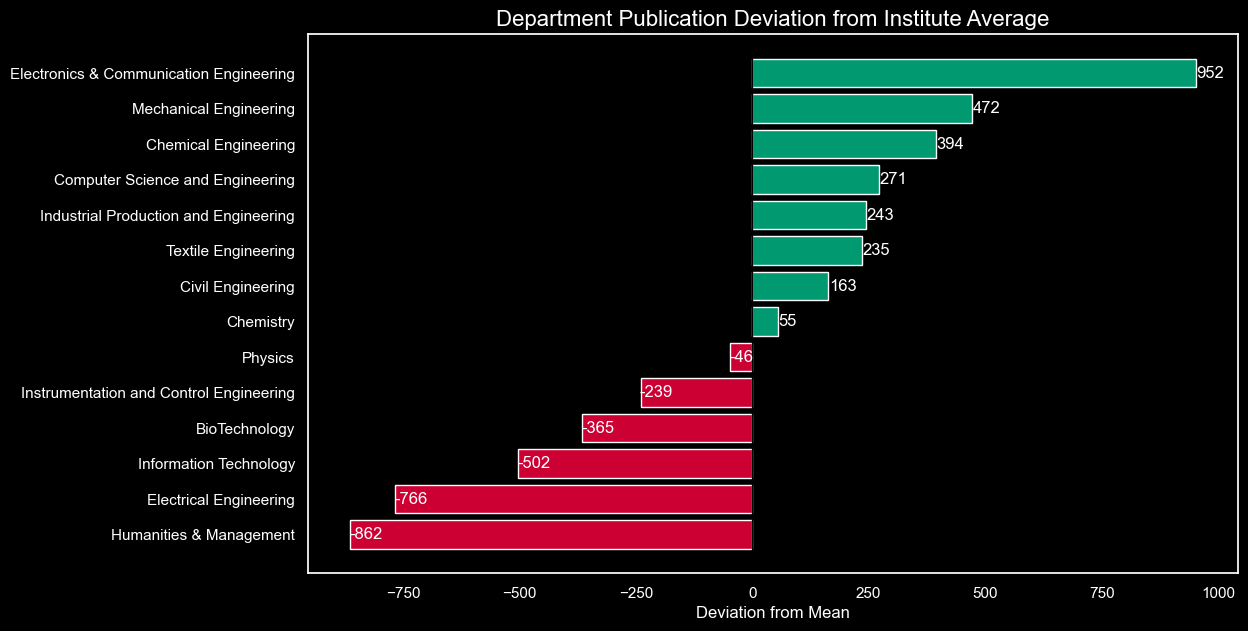

In [786]:
pubs = clean_df.groupby("Department")["Total Publications"].sum().sort_values()
mean_pub = pubs.mean()
diff = pubs - mean_pub

plt.figure(figsize=(12,7))
colors = diff.apply(lambda x: "#009970" if x > 0 else "#cc0033")

plt.barh(pubs.index, diff, color=colors)
plt.axvline(0, color='black', linewidth=1)

for val, name in zip(diff, pubs.index):
    plt.text(val + (1 if val > 0 else -1.5), name, f"{int(val)}", va='center')

plt.title("Department Publication Deviation from Institute Average", fontsize=16)
plt.xlabel("Deviation from Mean")
plt.ylabel("")
plt.show()


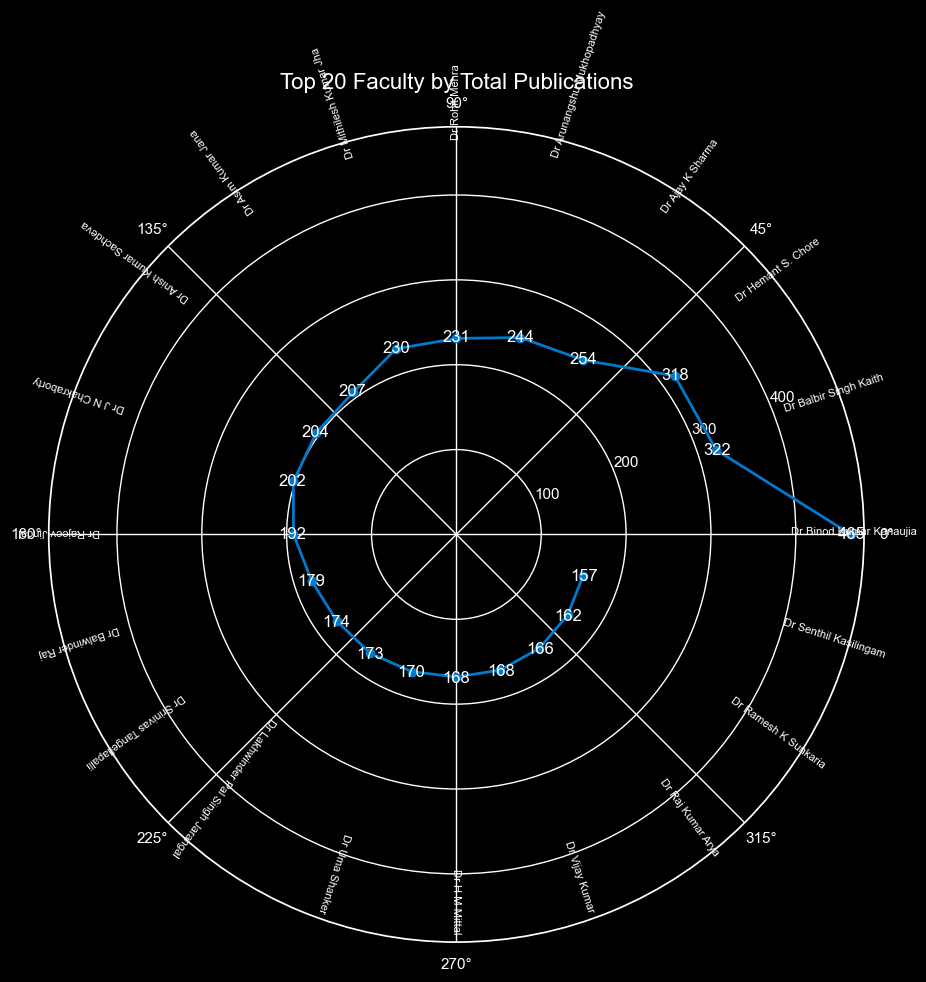

In [787]:
top10 = clean_df.sort_values("Total Publications", ascending=False).head(20)

plt.figure(figsize=(10,10))
angles = np.linspace(0, 2*np.pi, len(top10), endpoint=False)
values = top10["Total Publications"].values
names = top10["Name"].values

plt.polar(angles, values, 'o-', linewidth=2, color="#007acc")

for angle, value, name in zip(angles, values, names):
    plt.text(angle, value + 1, f"{value}", ha="center", va="center")
    plt.text(angle, max(values)+3, name, ha="center", rotation=angle*180/np.pi, fontsize=8)

plt.title("Top 20 Faculty by Total Publications", fontsize=16)
plt.tight_layout()
plt.show()

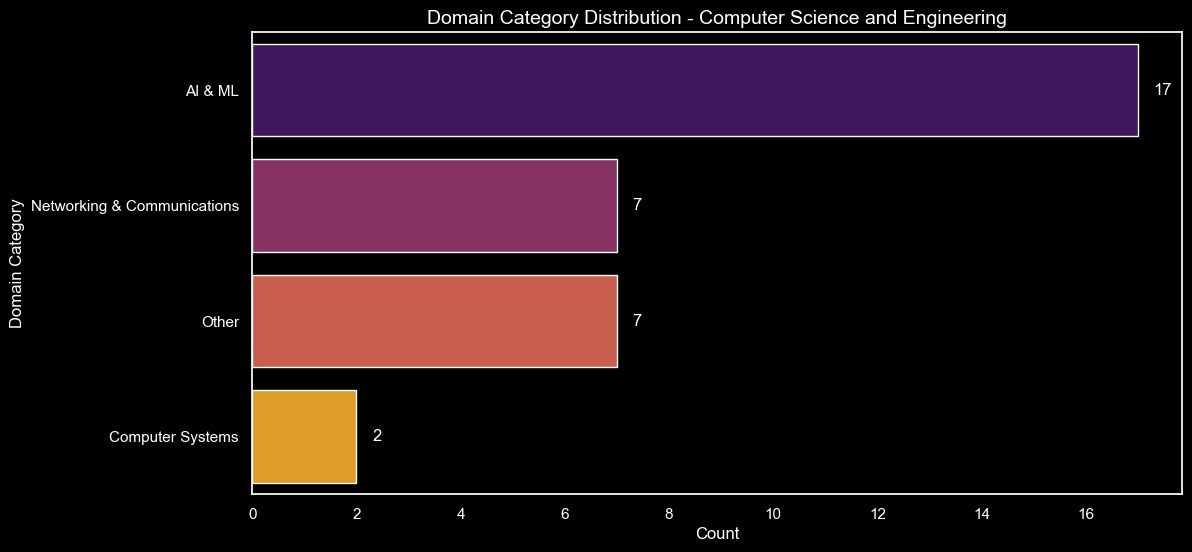

In [788]:
dept_name = "Computer Science and Engineering"
dept_df = clean_df[clean_df["Department"] == dept_name]
plt.figure(figsize=(12,6))
counts = dept_df["Domain Category"].value_counts()

sns.barplot(x=counts.values, y=counts.index, palette="inferno")

for i, v in enumerate(counts.values):
    plt.text(v + 0.3, i, str(v), va="center")

plt.title(f"Domain Category Distribution - {dept_name}")
plt.xlabel("Count")
plt.ylabel("Domain Category")
plt.show()


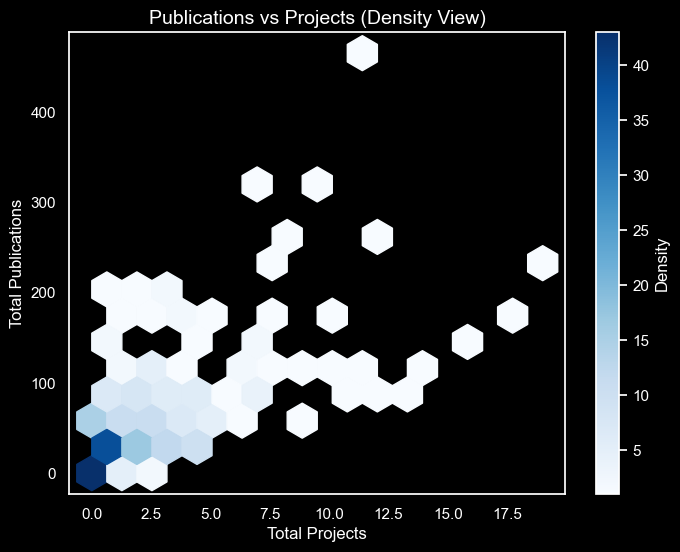

In [789]:
plt.figure(figsize=(8,6))
plt.hexbin(clean_df["Total_Projects"], clean_df["Total Publications"], gridsize=15, cmap="Blues", mincnt=1)
plt.colorbar(label="Density")
plt.xlabel("Total Projects")
plt.ylabel("Total Publications")
plt.title("Publications vs Projects (Density View)")
plt.show()


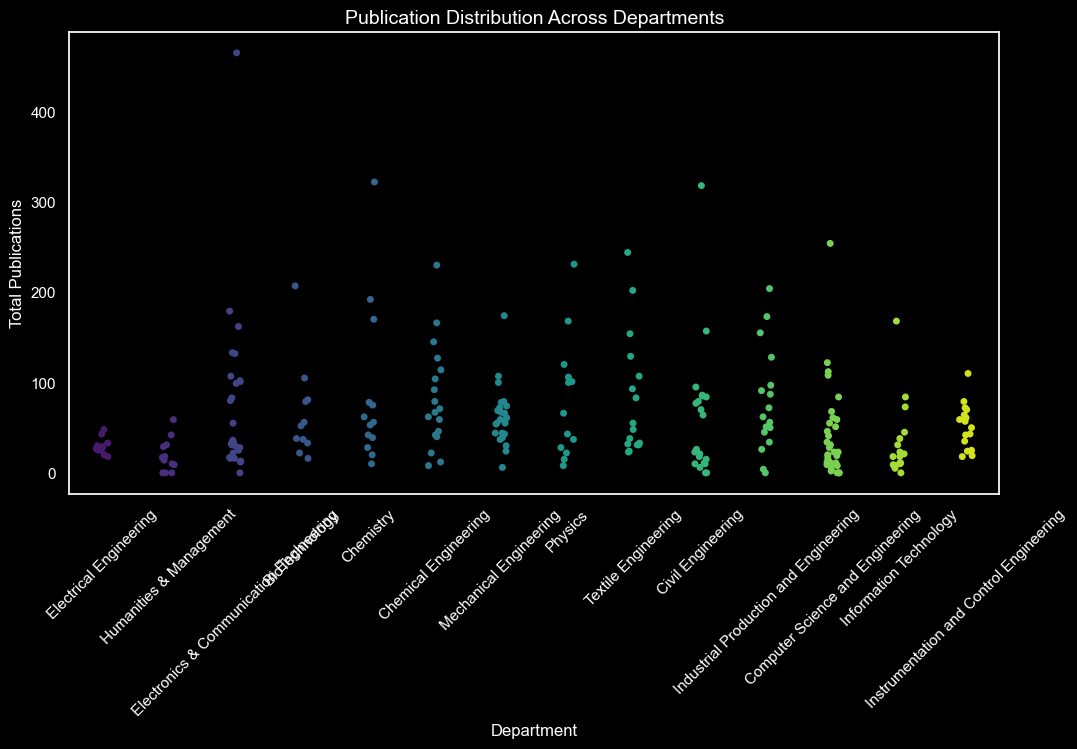

In [790]:
plt.figure(figsize=(12,6))
sns.stripplot(data=clean_df, x="Department", y="Total Publications", jitter=True, palette="viridis")
plt.xticks(rotation=45)
plt.title("Publication Distribution Across Departments")
plt.show()


In [791]:
import pandas as pd
import plotly.graph_objects as go

# df = your final_cleaned_data dataframe

# Step 1: Build node lists
departments = clean_df["Department"].unique().tolist()
domains = clean_df["Domain Category"].unique().tolist()

nodes = departments + domains

# Mapping names → integer indices
node_index = {name: i for i, name in enumerate(nodes)}

# Step 2: Build link data (source → target → value)
links = (
    clean_df.groupby(["Department", "Domain Category"])["Name"]
    .count()
    .reset_index()
    .rename(columns={"Name": "value"})
)

source_indices = links["Department"].map(node_index).tolist()
target_indices = links["Domain Category"].map(node_index).tolist()

values = links["value"].tolist()

# Step 3: Draw Sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.3),
        label=nodes,
        color=["#007acc"]*len(departments) + ["#00A676"]*len(domains)
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        color="rgba(150,150,150,0.4)"
    )
)])

fig.update_layout(
    title="Department → Research Domain Category Flow",
    font_size=12,
    height=800,
)

fig.show()


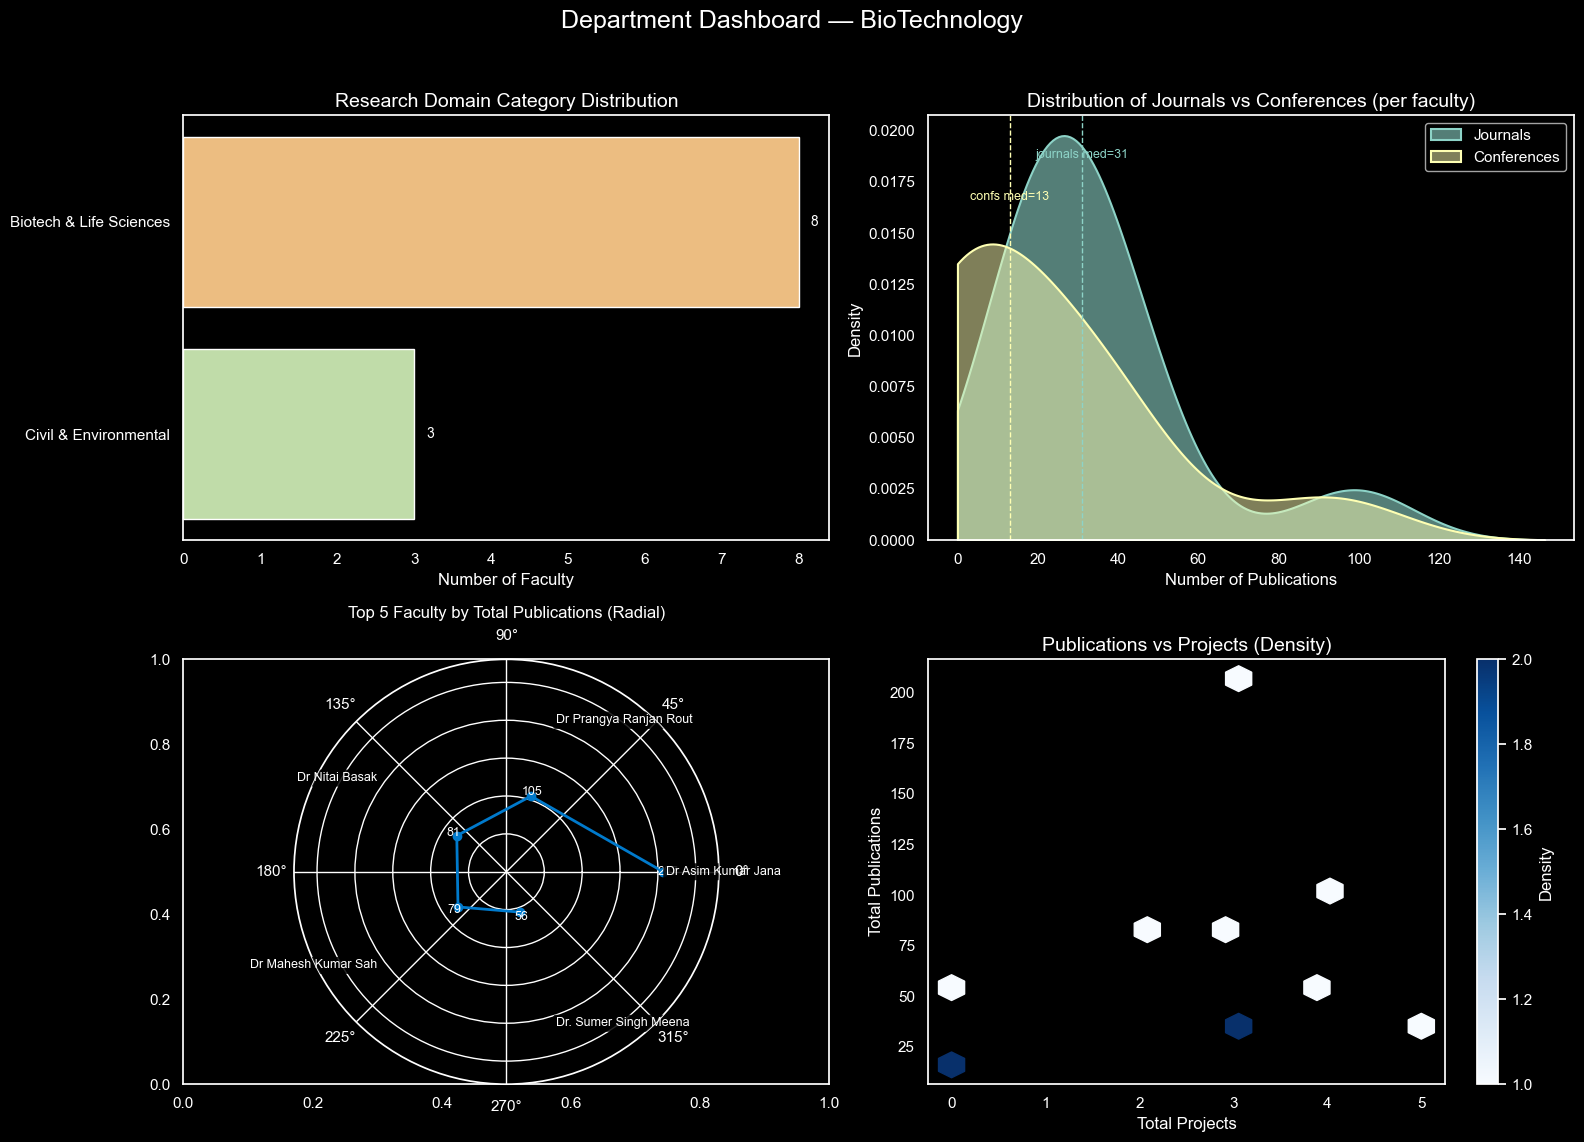

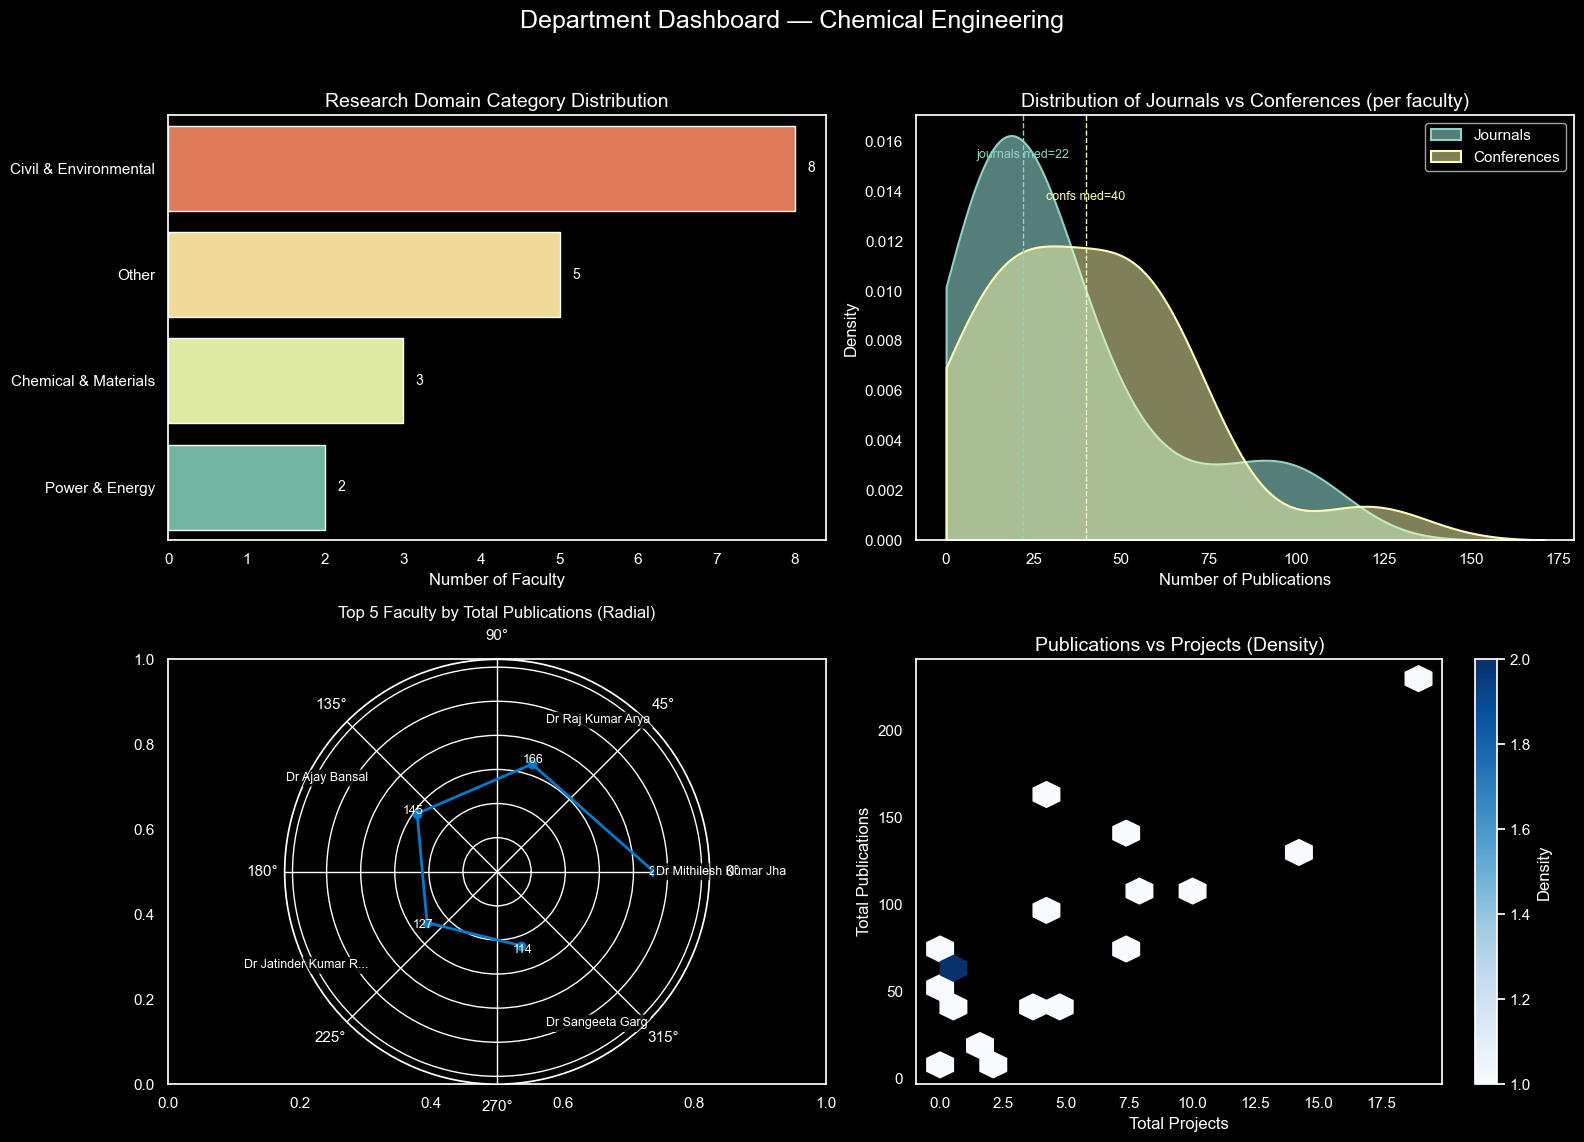

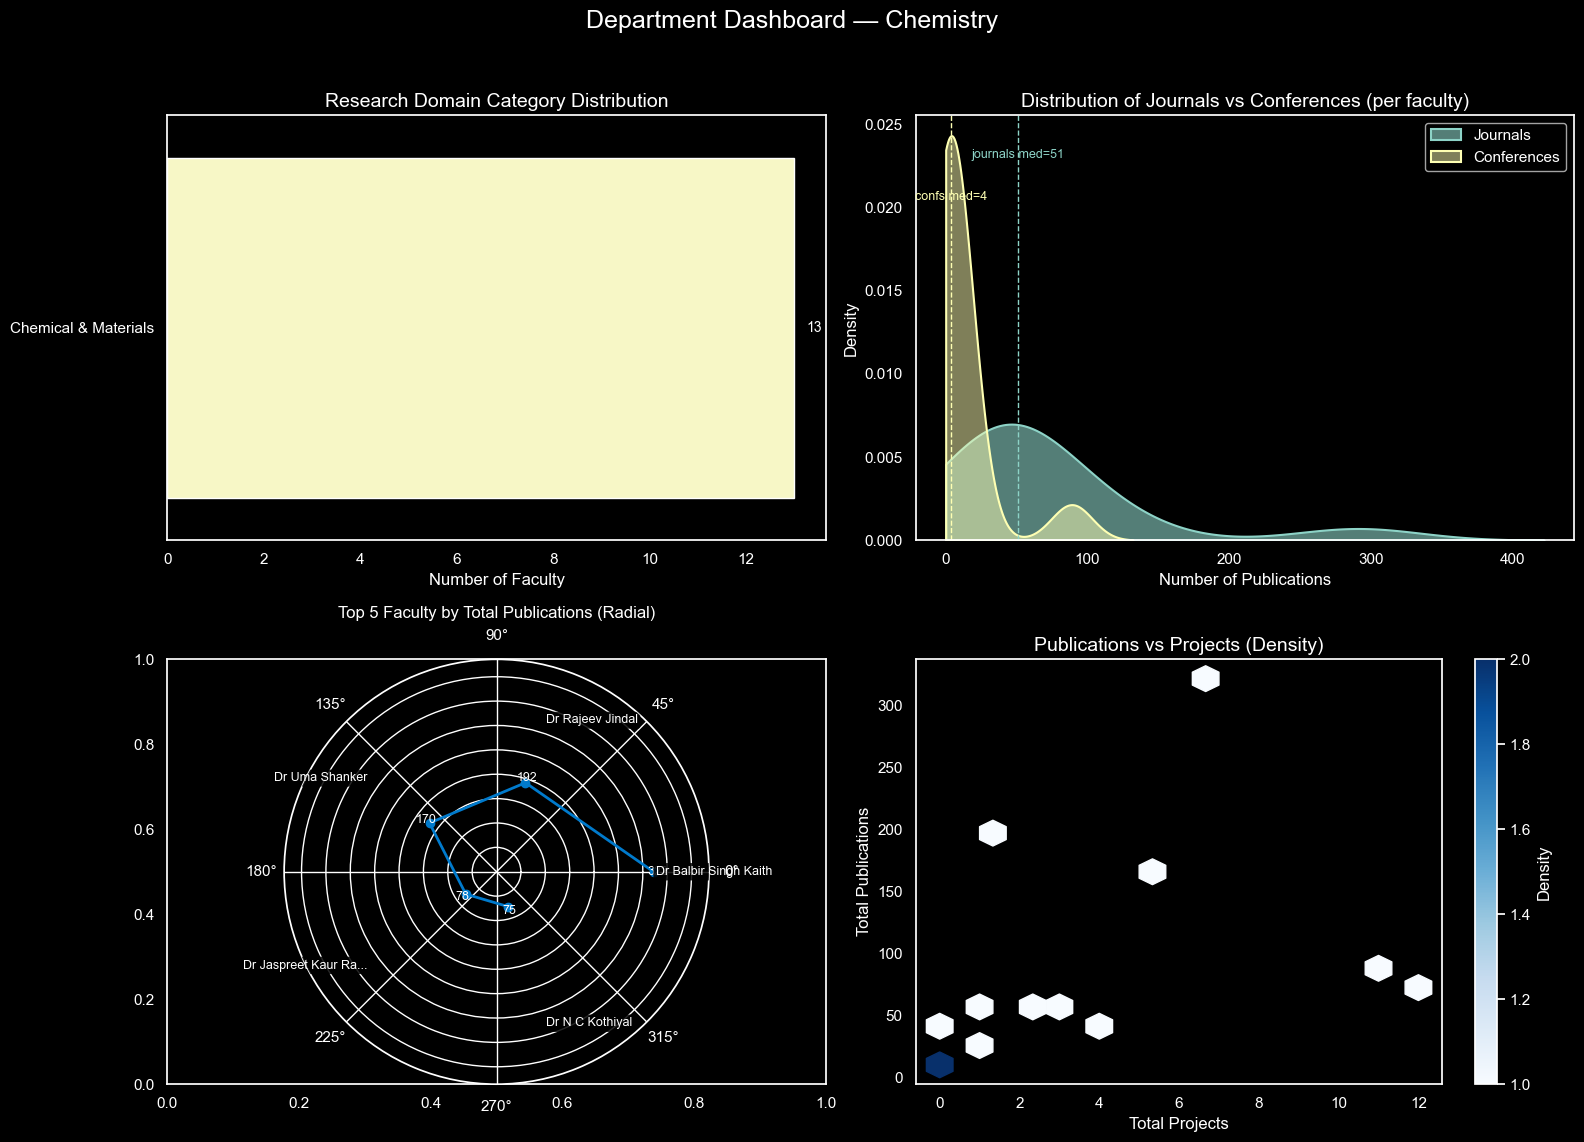

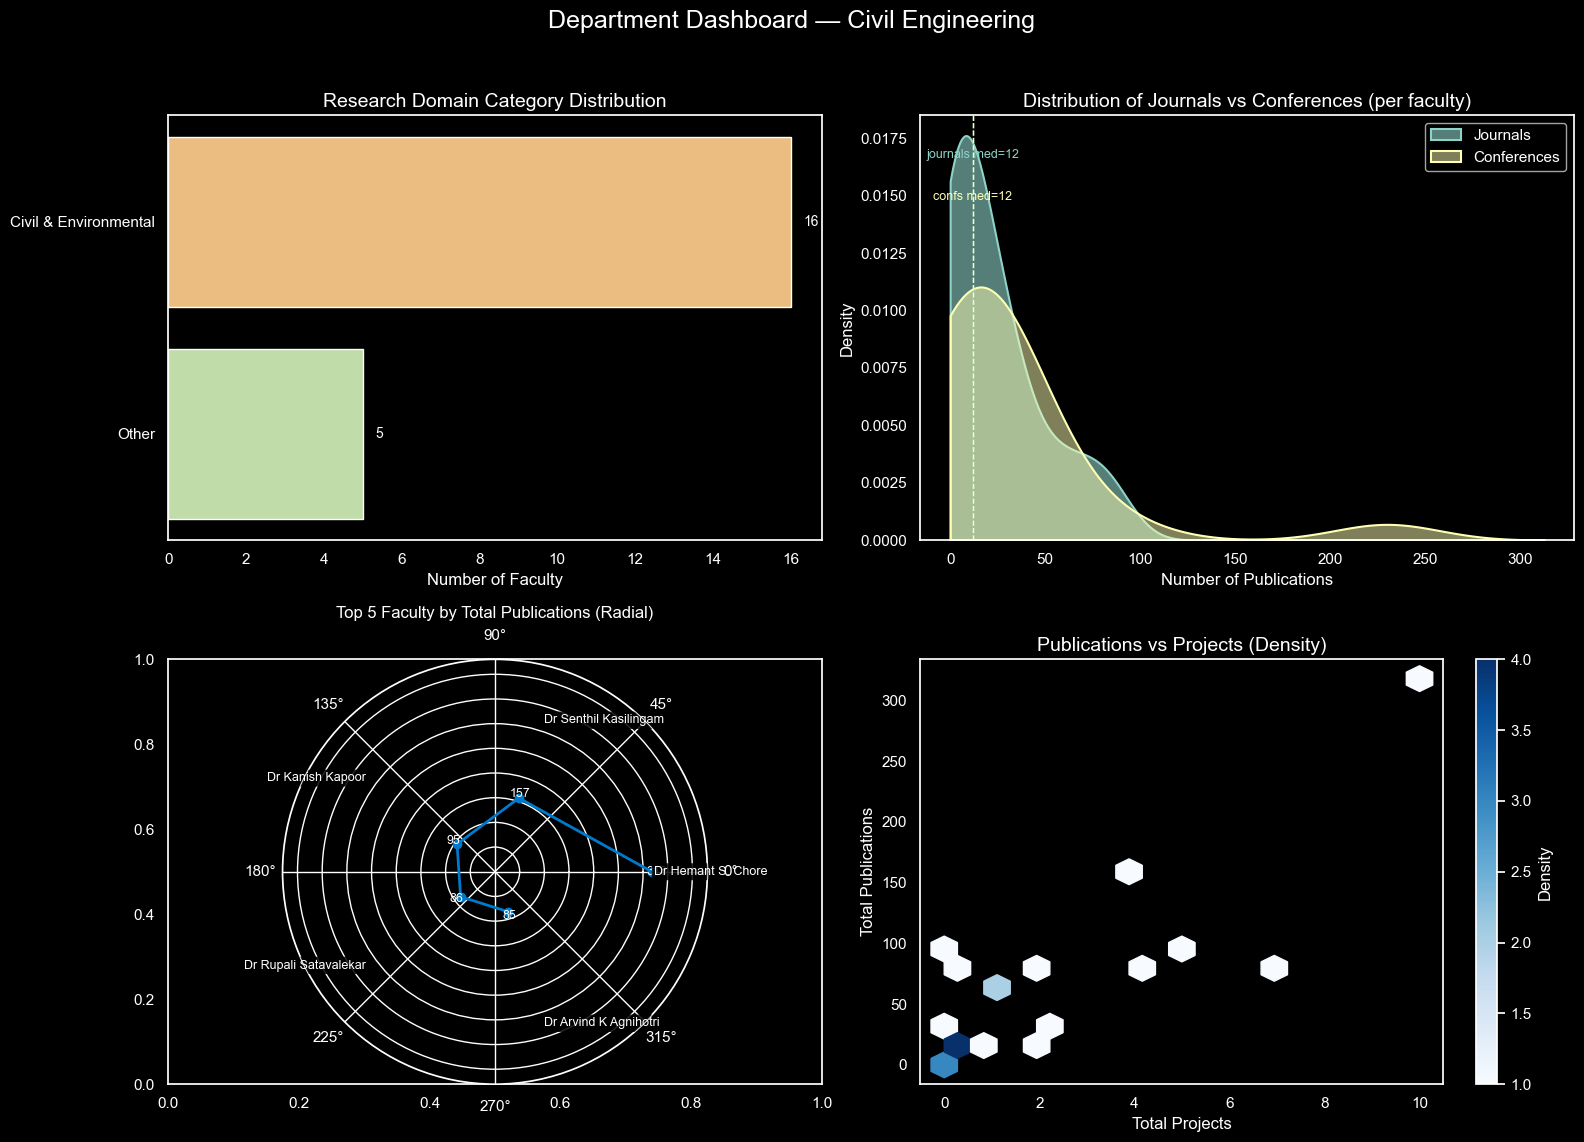

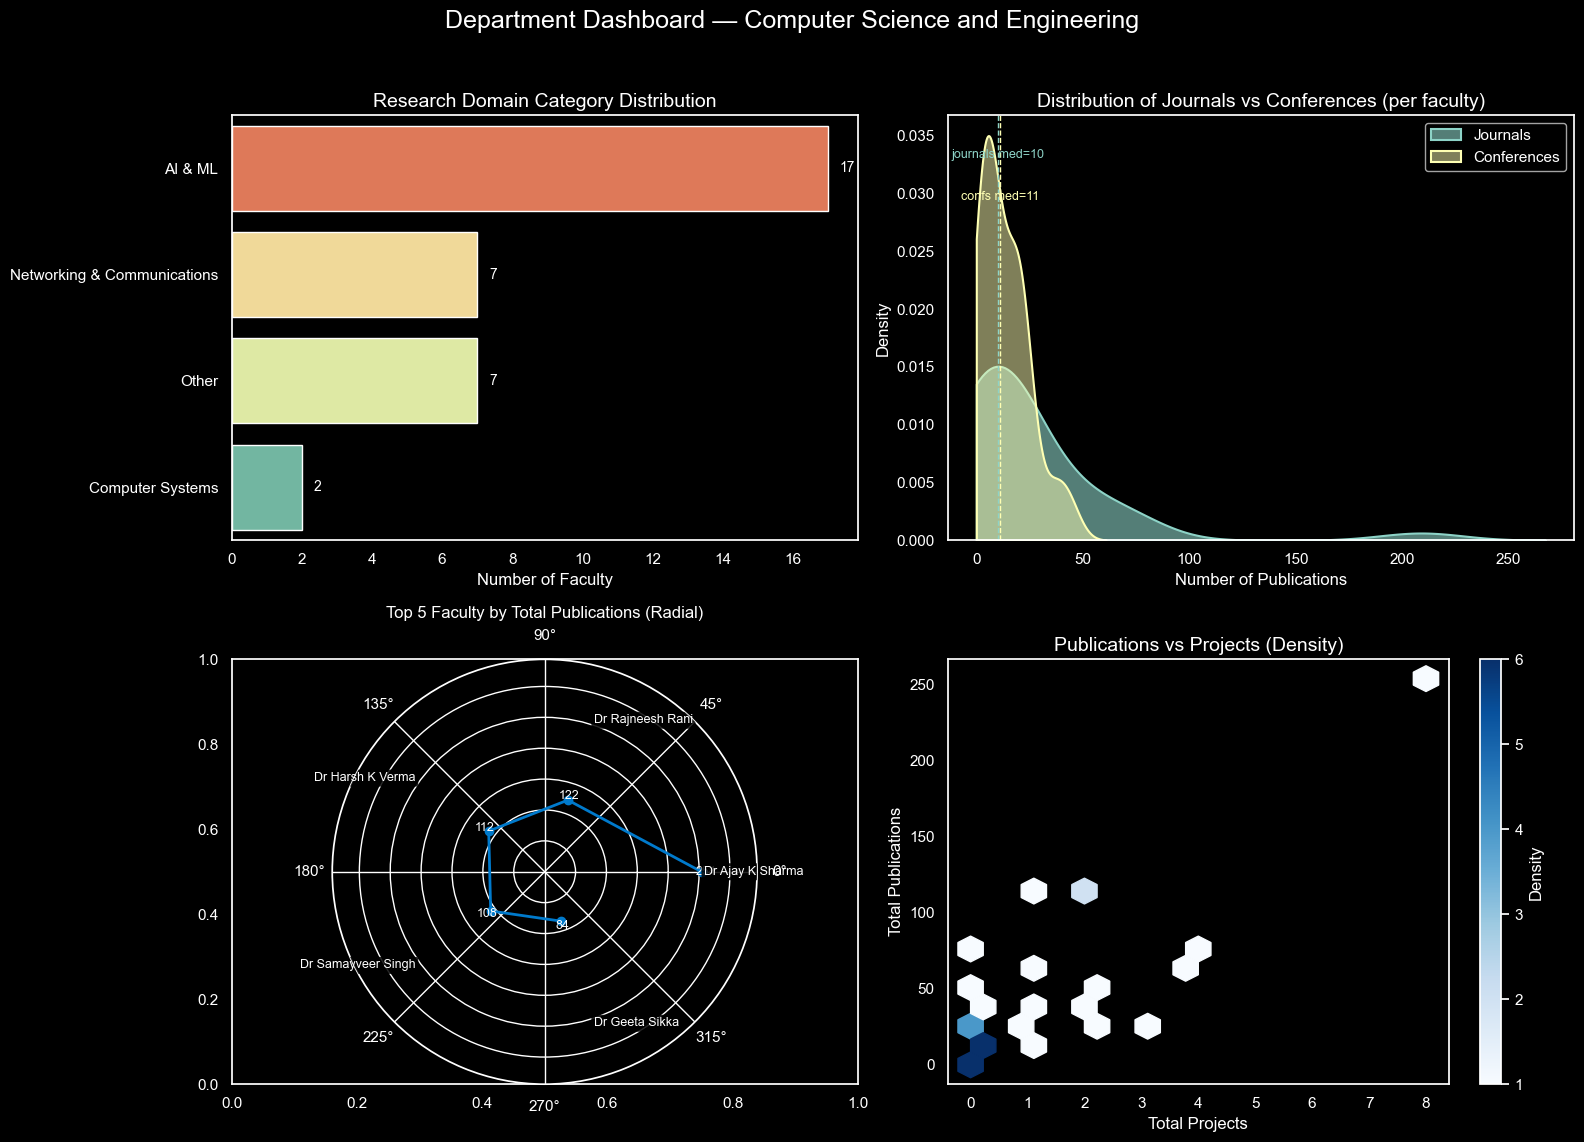

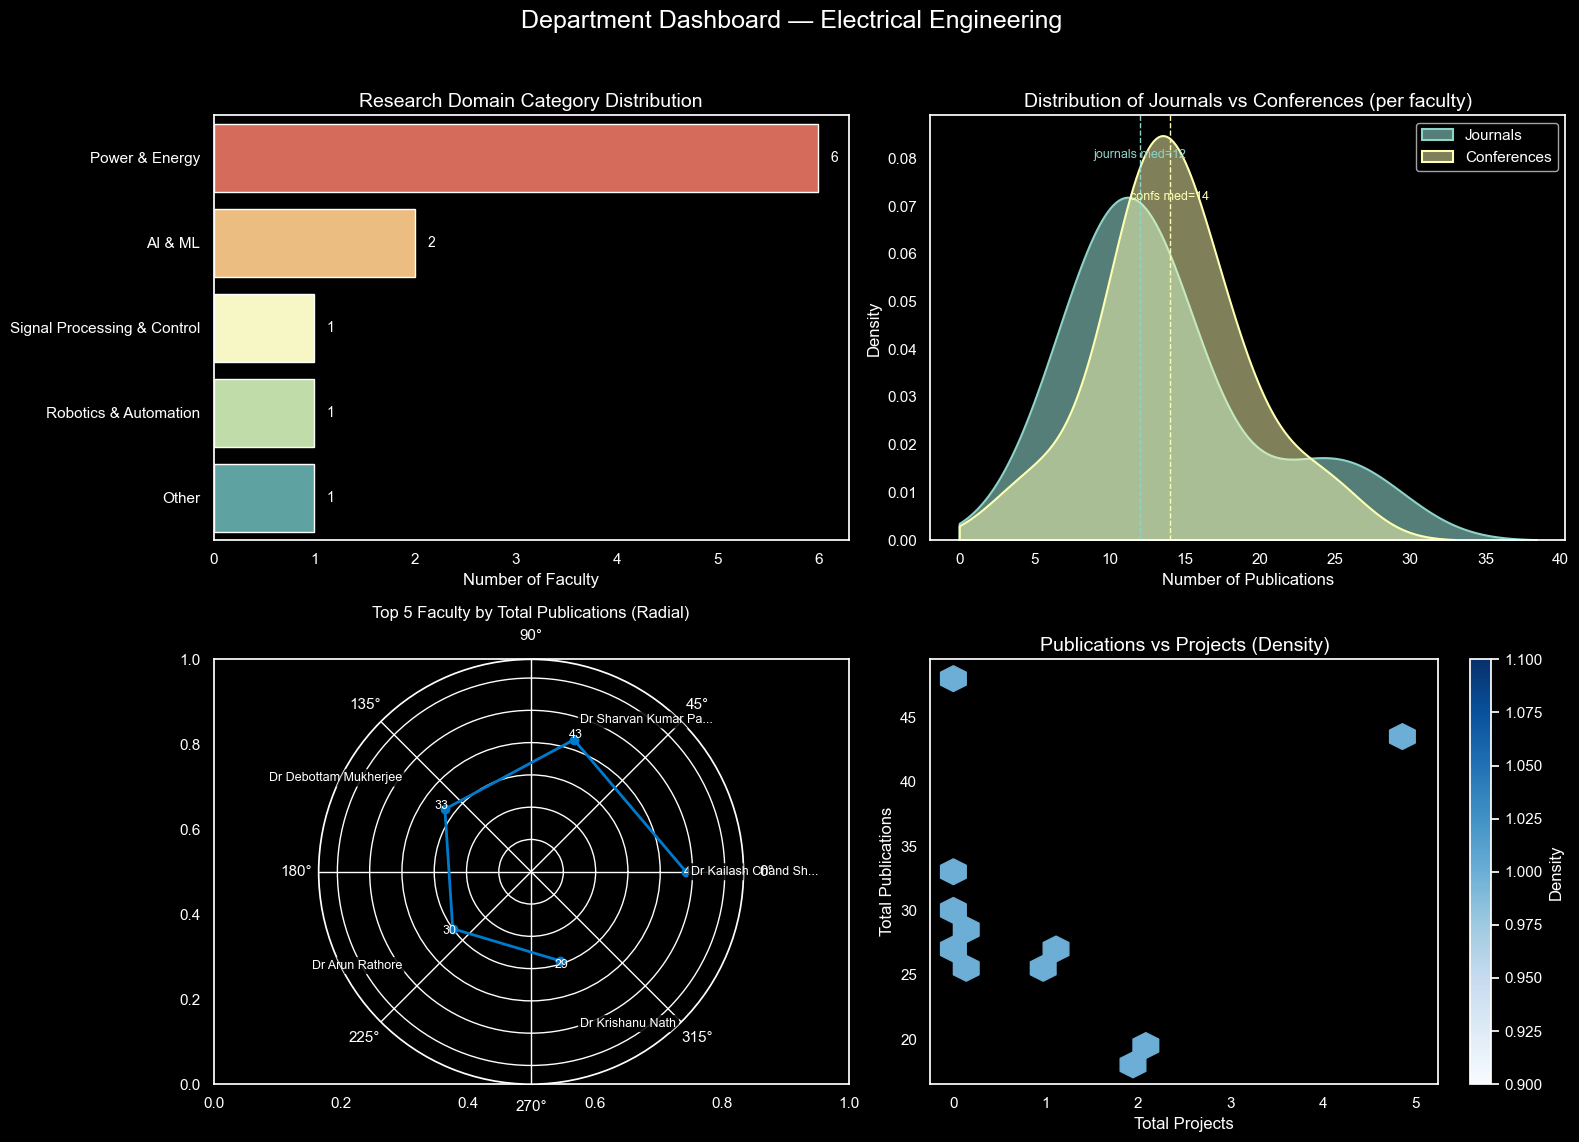

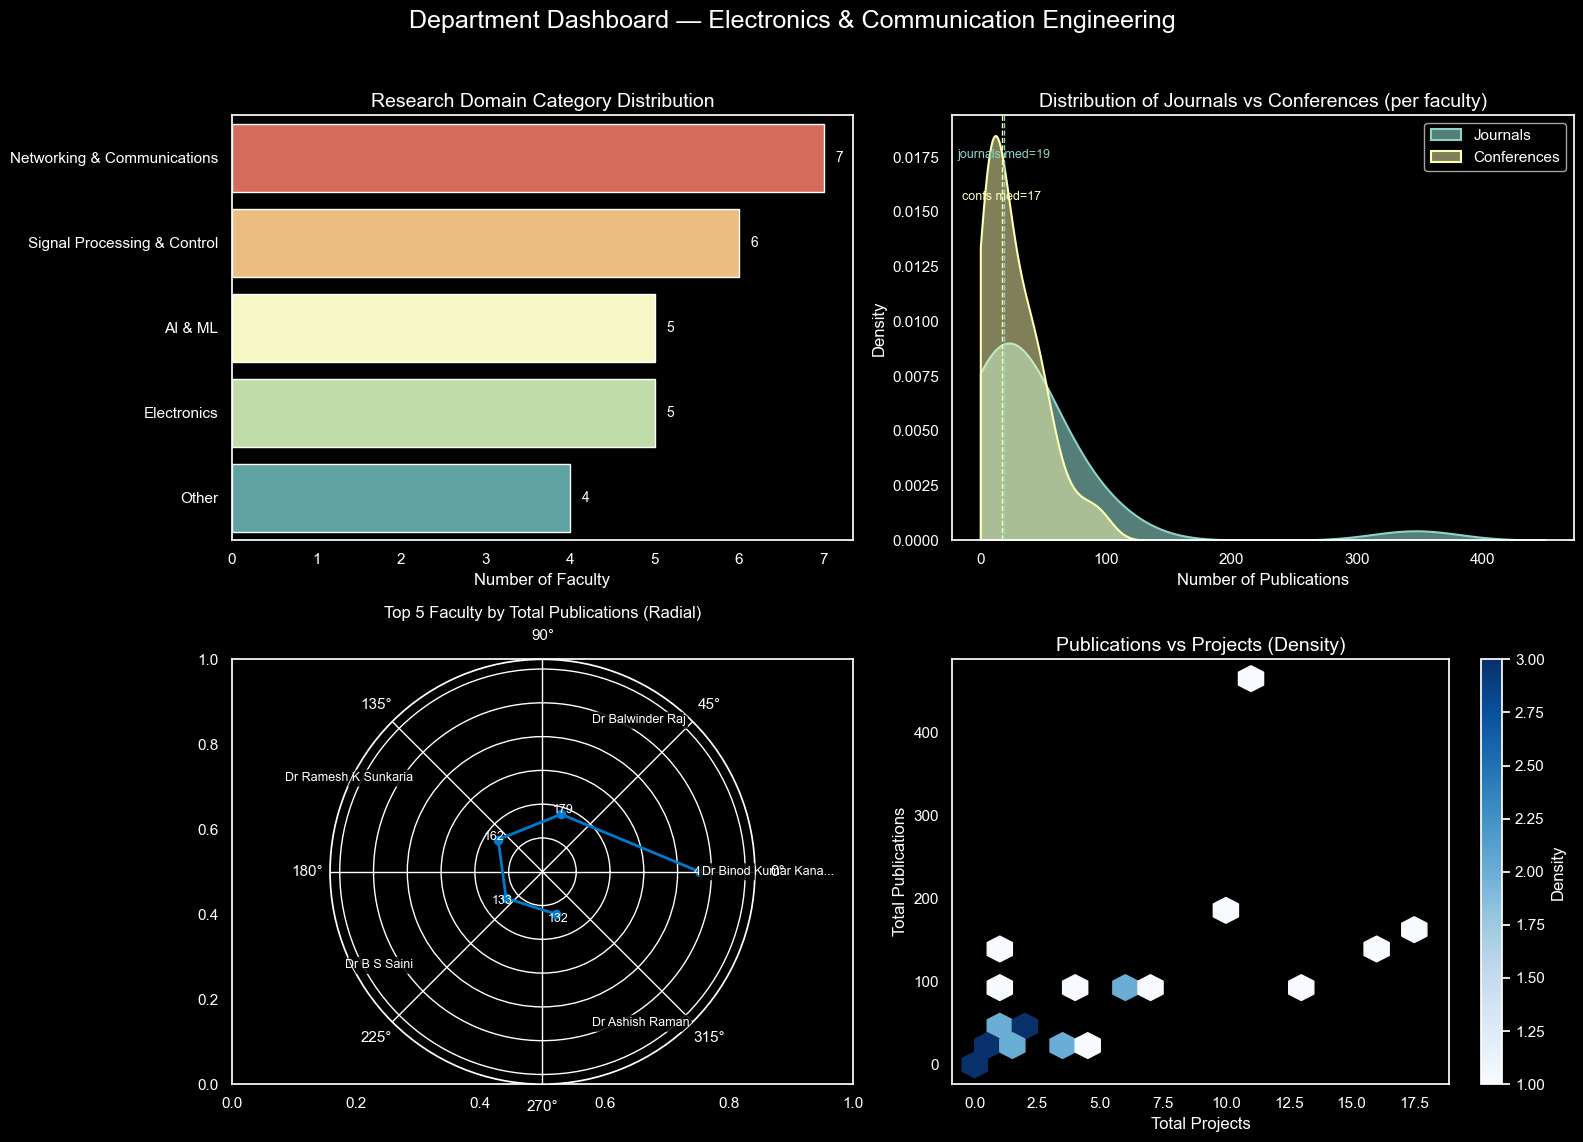

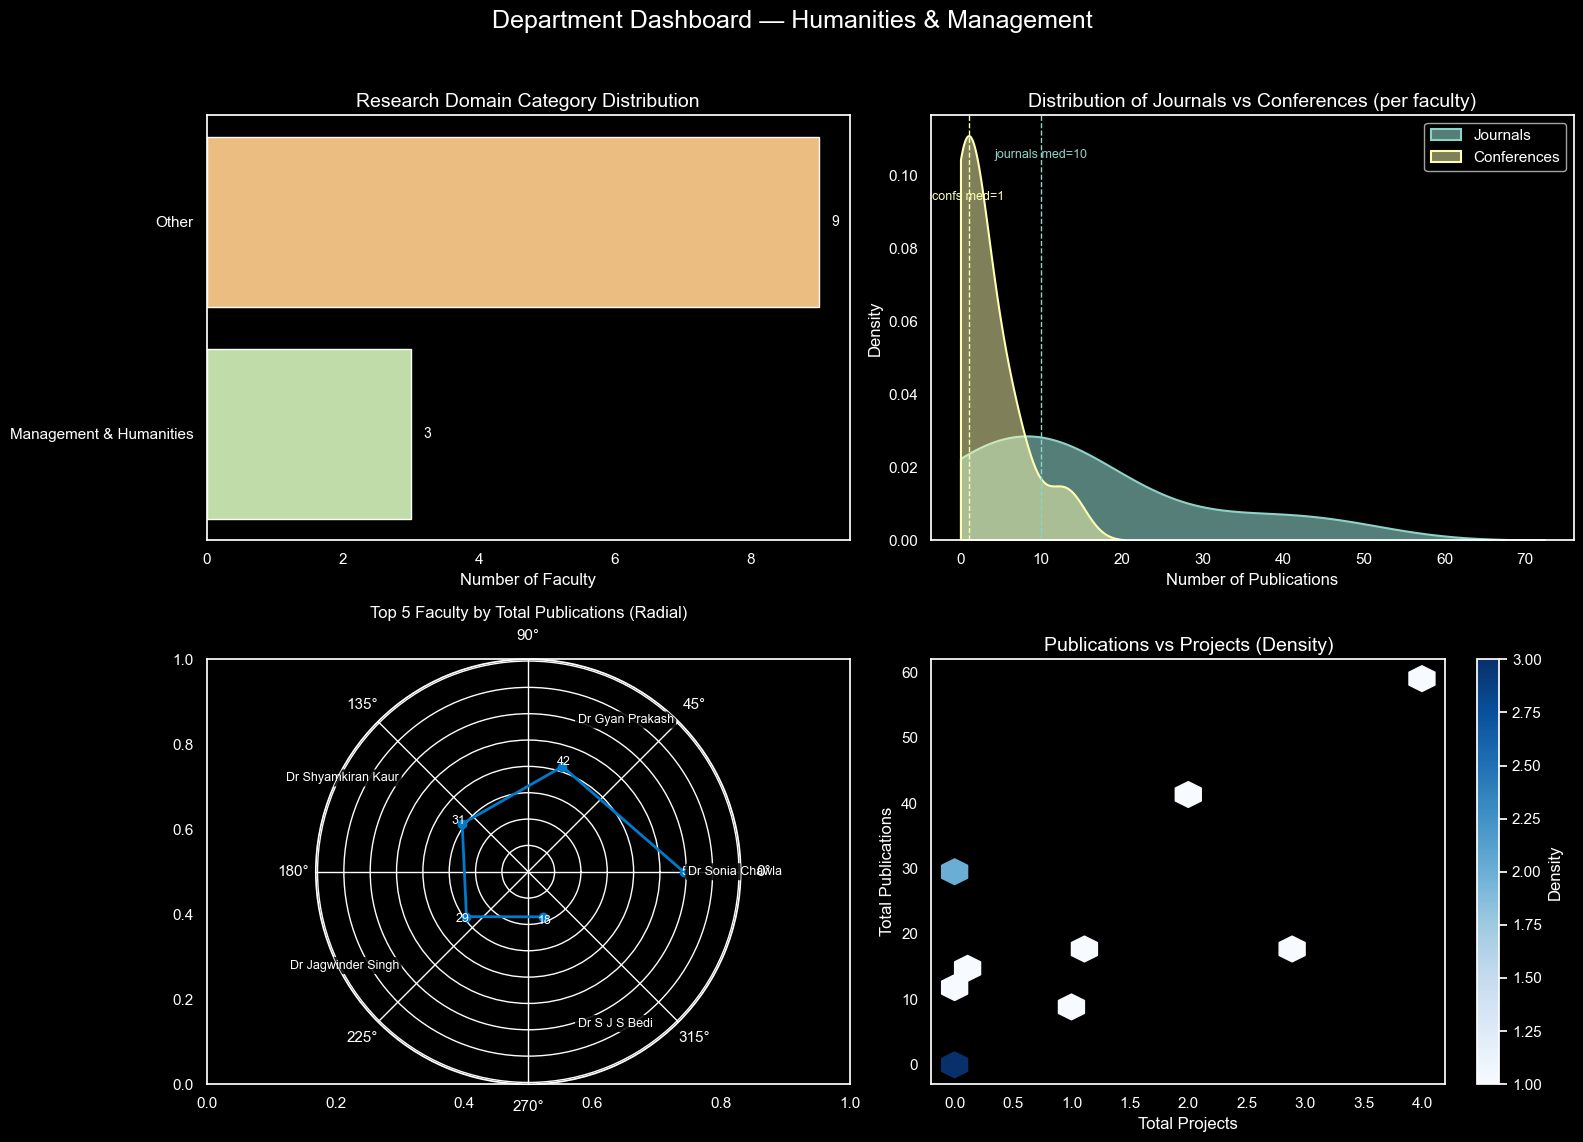

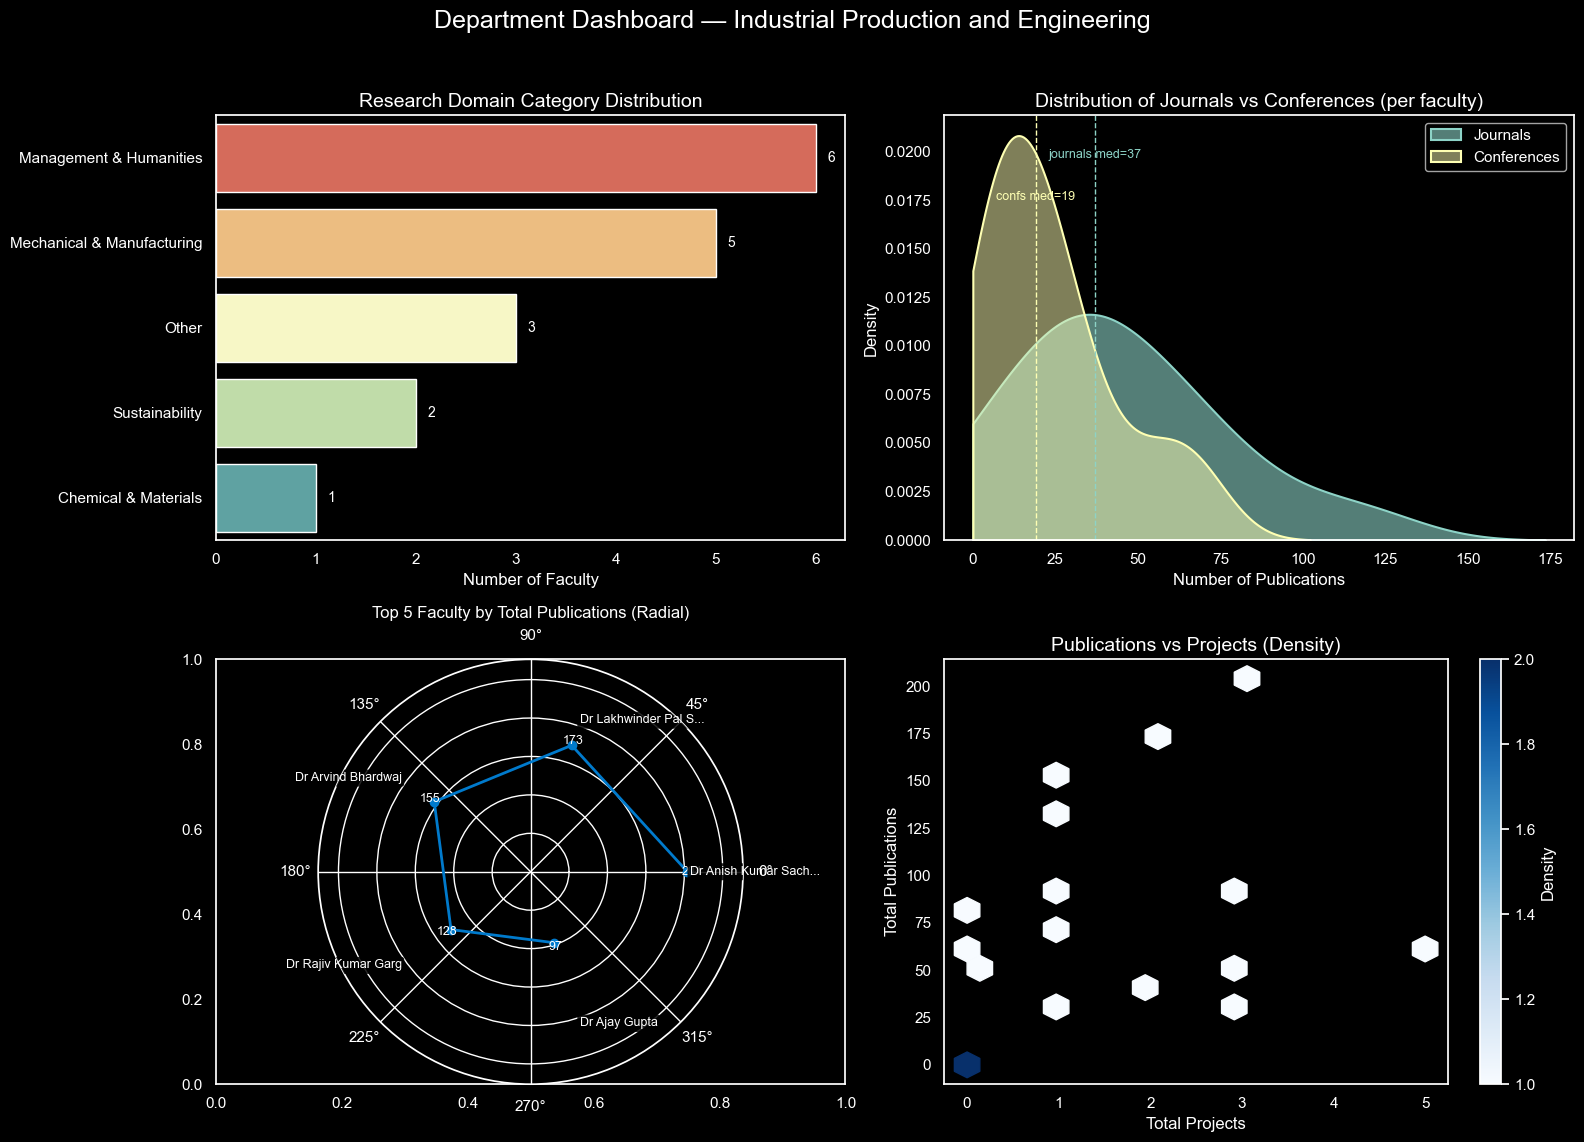

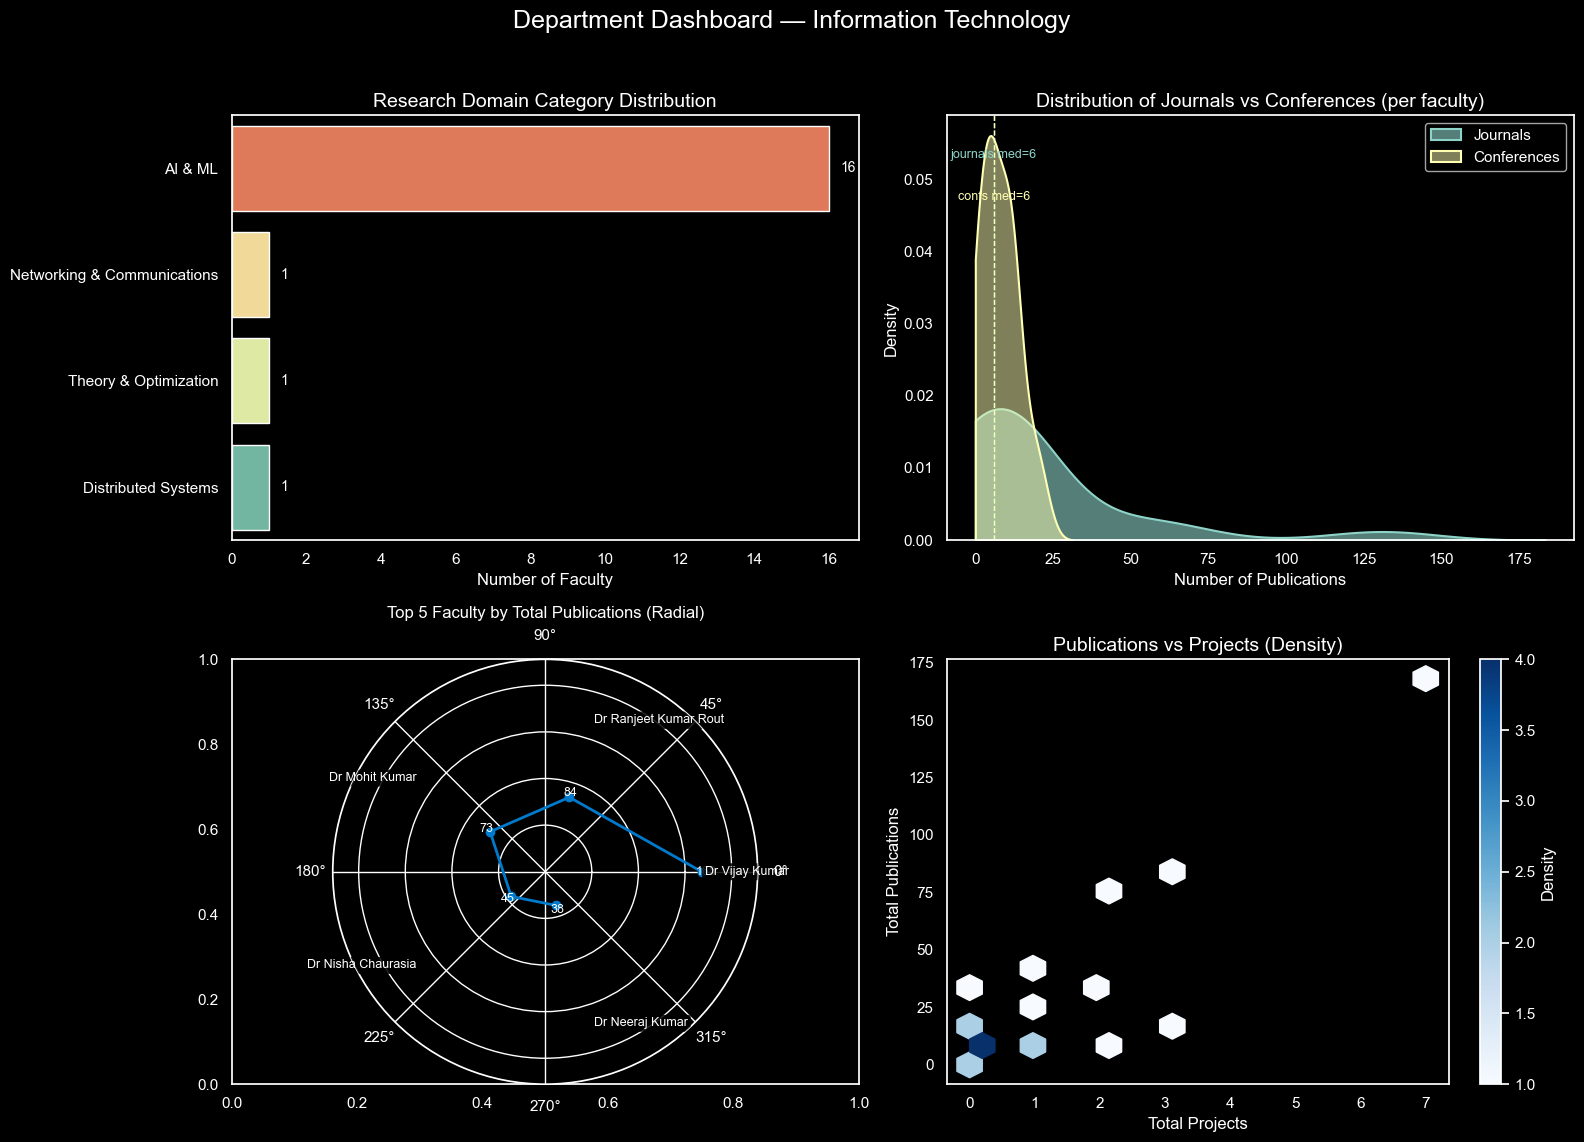

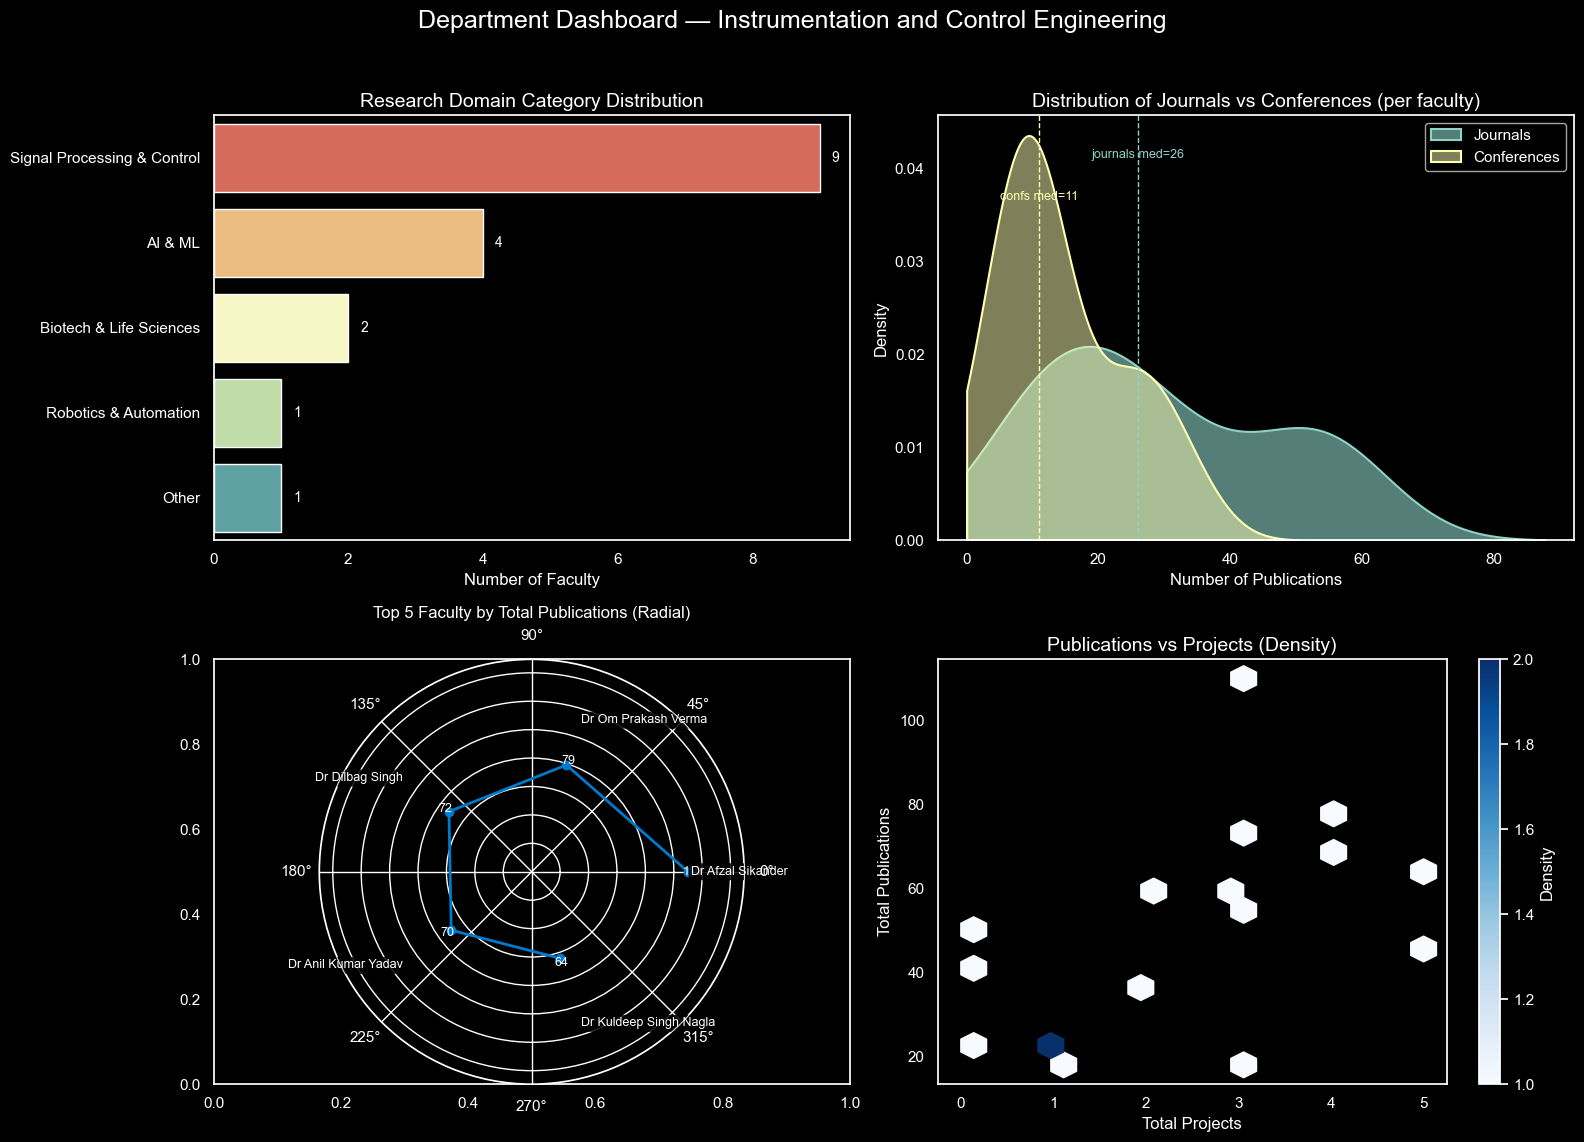

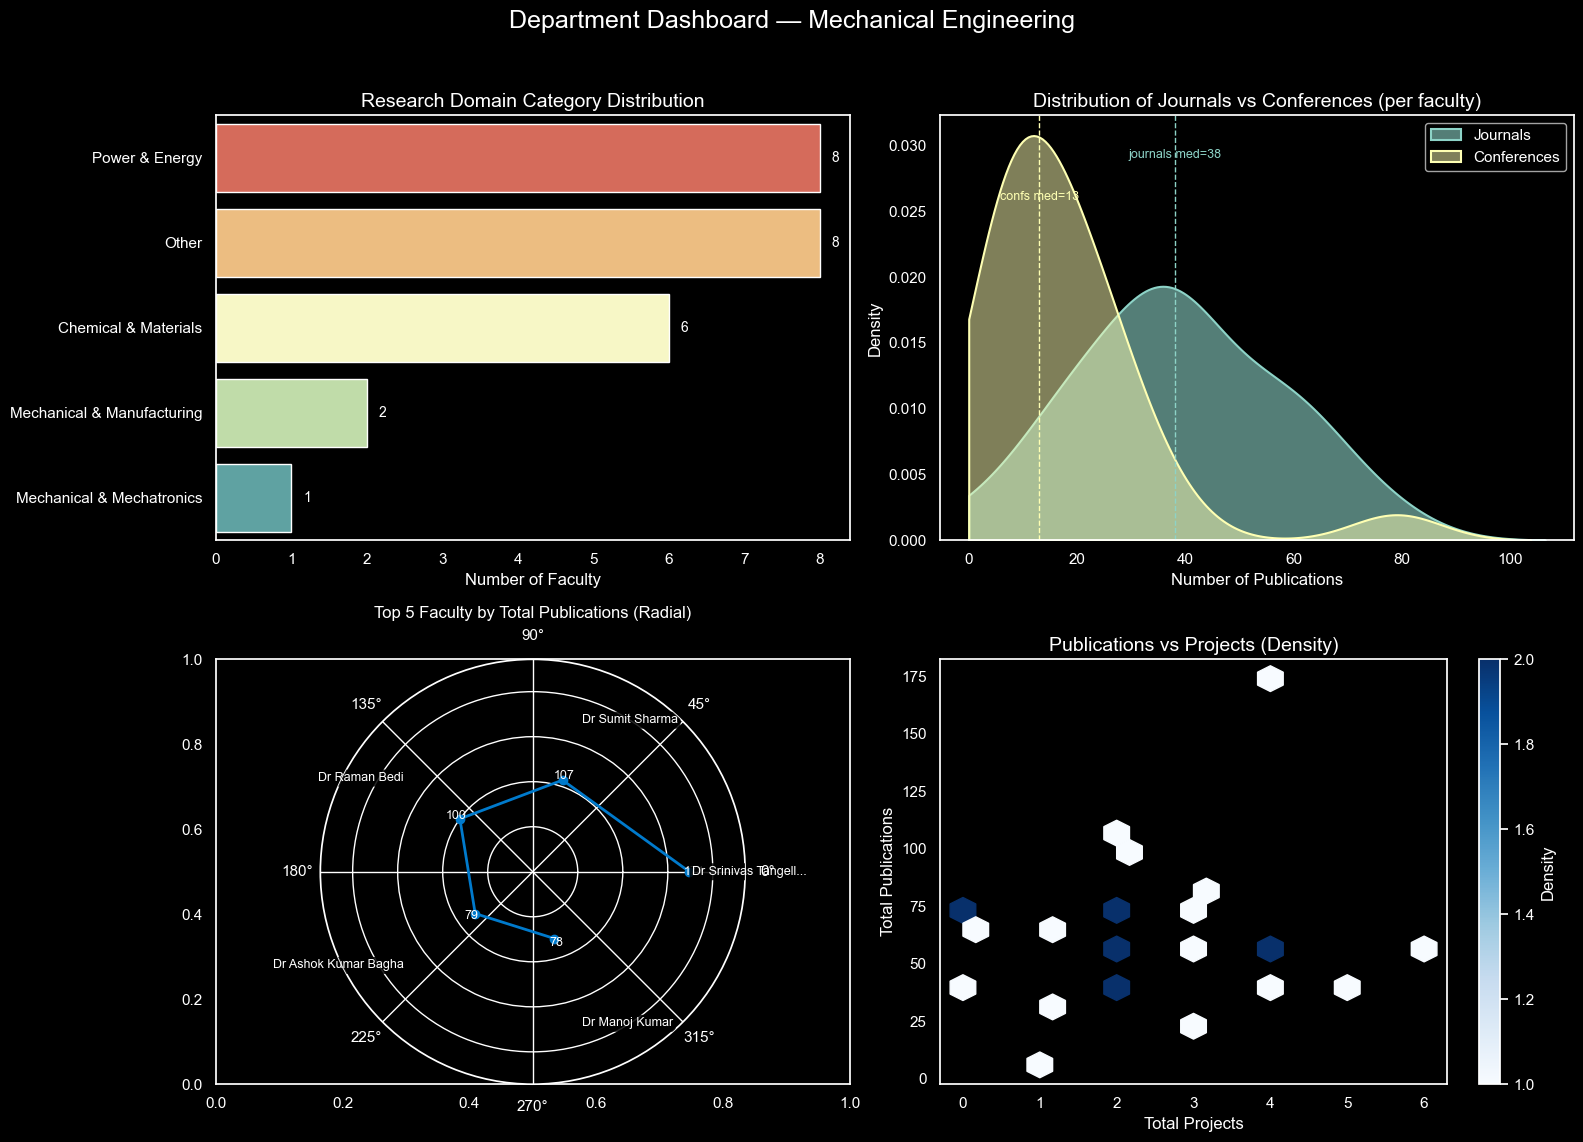

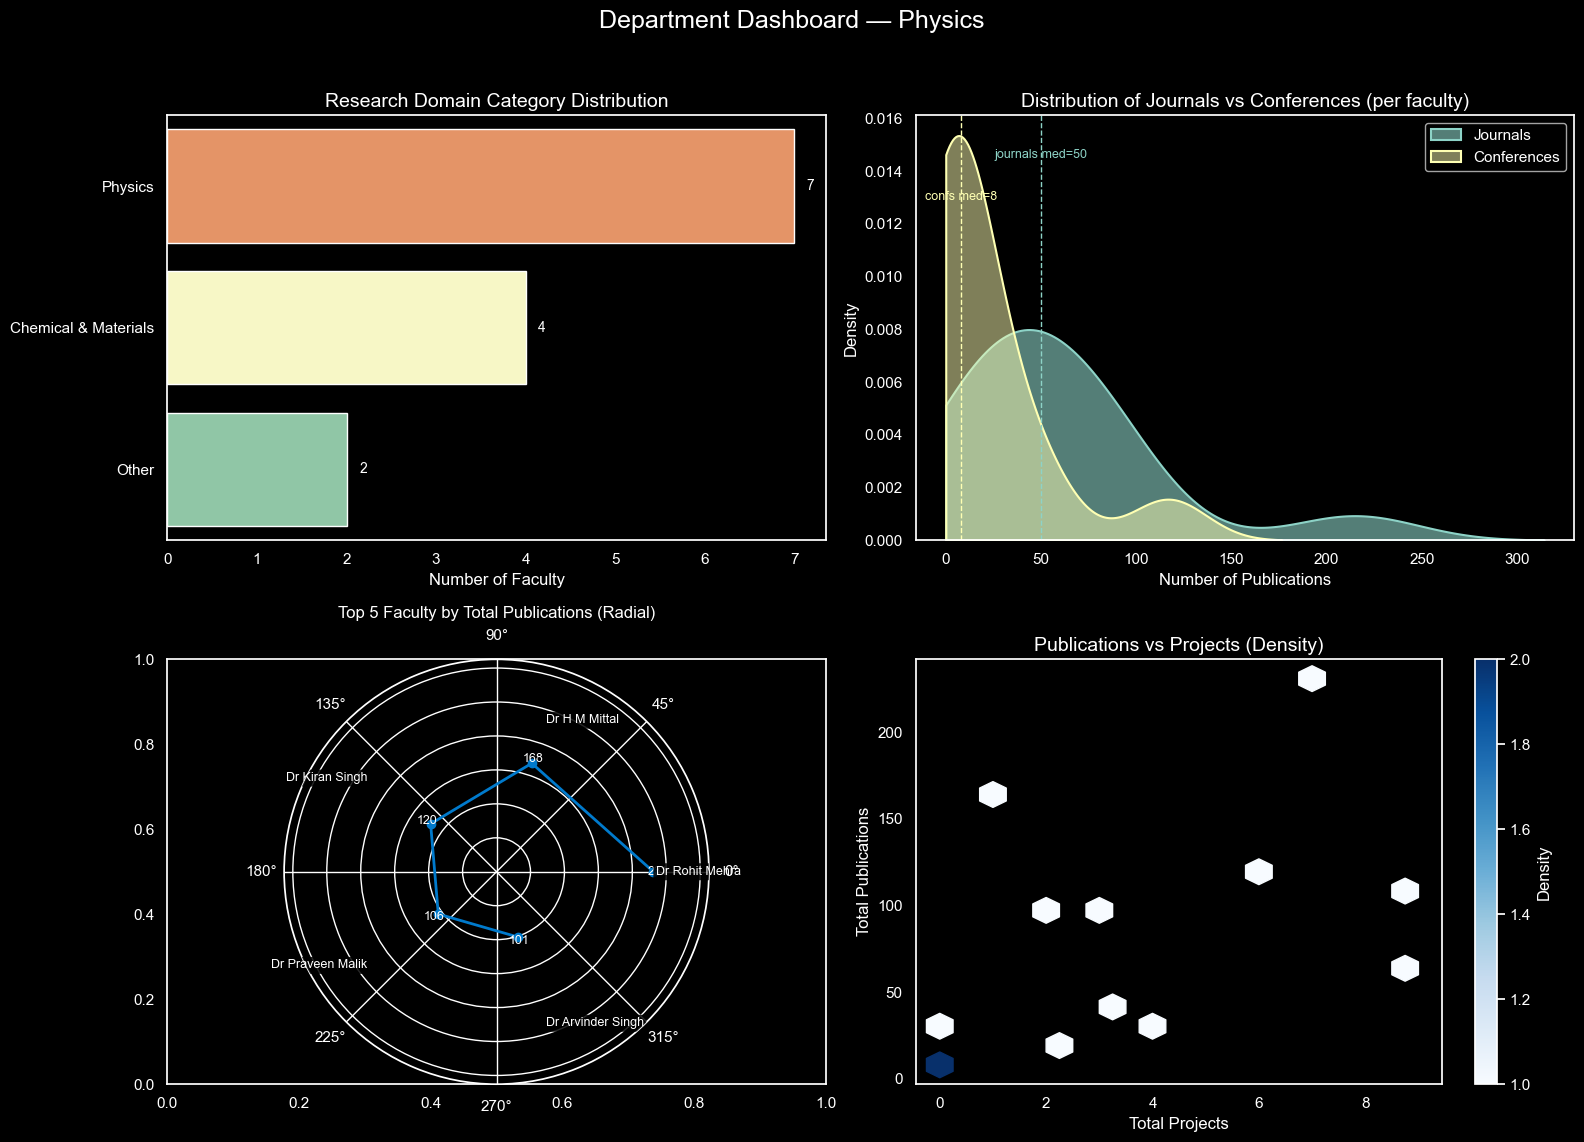

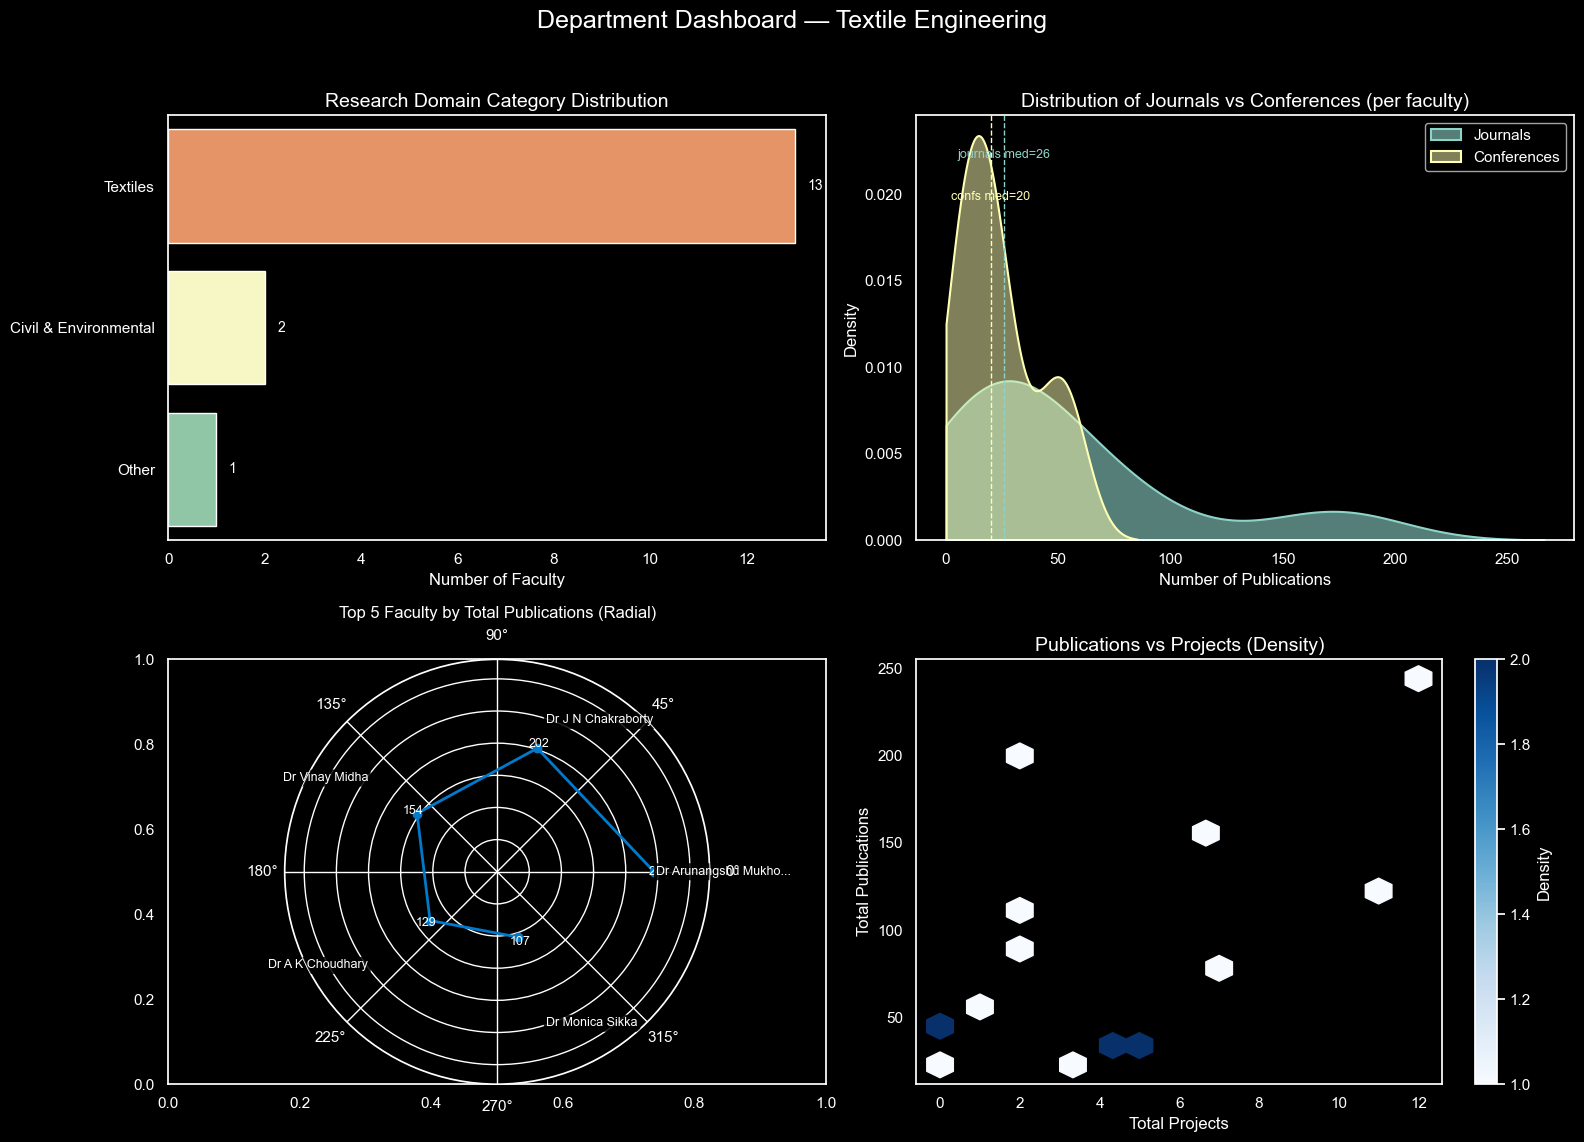

In [792]:
# Full per-department plotting script (4 plots per department)

# Ensure numeric columns exist to avoid key errors
for col in ["No. of Journal Publications", "No. of Conference Publications",
            "Total Publications", "Total_Projects"]:
    if col not in clean_df.columns:
        clean_df[col] = 0

# Ensure Has_Projects exists
if "Has_Projects" not in clean_df.columns:
    if "Total_Projects" in clean_df.columns:
        clean_df["Has_Projects"] = clean_df["Total_Projects"] > 0
    else:
        clean_df["Has_Projects"] = False

# Sorted list of departments
departments = sorted(clean_df["Department"].dropna().unique().tolist())

# Helper: annotate horizontal bar chart values
def annotate_barh(ax, values, labels, xpad=0.02):
    maxv = max(values) if len(values) > 0 else 1
    for i, v in enumerate(values):
        ax.text(v + xpad * maxv, i, str(int(v)), va='center', fontsize=10)

# Helper: truncate names (no textwrap)
def truncate_name(s, max_chars=22):
    s = str(s)
    return s if len(s) <= max_chars else s[:max_chars-3] + "..."

# Main loop: produce 4 plots per department (2x2 grid)
for dept in departments:
    dept_df = clean_df[clean_df["Department"] == dept]
    if dept_df.empty:
        continue

    # Prepare data for plots
    domain_counts = dept_df["Domain Category"].value_counts()
    journals_arr = dept_df["No. of Journal Publications"].values
    conf_arr = dept_df["No. of Conference Publications"].values
    top5 = dept_df.sort_values("Total Publications", ascending=False).head(5)
    pub_vals = dept_df["Total Publications"].values
    proj_vals = dept_df["Total_Projects"].values if "Total_Projects" in dept_df.columns else np.zeros(len(pub_vals))

    # Create 2x2 layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Department Dashboard — {dept}", fontsize=18, y=0.98)

    # 1) Domain Category Distribution (annotated horizontal bar)
    ax1 = axes[0, 0]
    if len(domain_counts) > 0:
        sns.barplot(x=domain_counts.values, y=domain_counts.index, palette="Spectral", ax=ax1)
        annotate_barh(ax1, domain_counts.values, domain_counts.index)
        ax1.set_title("Research Domain Category Distribution")
        ax1.set_xlabel("Number of Faculty")
        ax1.set_ylabel("")
    else:
        ax1.text(0.5, 0.5, "No domain category data", ha="center", va="center")
        ax1.set_axis_off()

    # 2) KDE: Distribution of Journals vs Conferences (per-faculty)
    ax2 = axes[0, 1]
    if (journals_arr.sum() == 0) and (conf_arr.sum() == 0):
        ax2.text(0.5, 0.5, "No publication data for this department", ha="center", va="center")
        ax2.set_axis_off()
    else:
        jitter = 1e-6
        plotted = False
        if len(journals_arr) > 1 and np.any(journals_arr > 0):
            sns.kdeplot(journals_arr + jitter, fill=True, label="Journals", ax=ax2,
                        alpha=0.6, linewidth=1.5, clip=(0, None))
            plotted = True
        if len(conf_arr) > 1 and np.any(conf_arr > 0):
            sns.kdeplot(conf_arr + jitter, fill=True, label="Conferences", ax=ax2,
                        alpha=0.5, linewidth=1.5, clip=(0, None))
            plotted = True
        # If both are zeros (or too few non-zero points), fallback to small histogram
        if not plotted:
            ax2.hist([journals_arr, conf_arr], label=["Journals", "Conferences"], bins=5, stacked=False)
        ax2.set_title("Distribution of Journals vs Conferences (per faculty)")
        ax2.set_xlabel("Number of Publications")
        ax2.set_ylabel("Density")
        ax2.legend()
        # annotate medians if available
        j_med = int(np.median(journals_arr)) if len(journals_arr) > 0 else 0
        c_med = int(np.median(conf_arr)) if len(conf_arr) > 0 else 0
        ylim = ax2.get_ylim()
        ax2.axvline(j_med, color='C0', linestyle='--', linewidth=1)
        ax2.axvline(c_med, color='C1', linestyle='--', linewidth=1)
        ax2.text(j_med, ylim[1]*0.90, f"journals med={j_med}", color='C0', fontsize=9, ha='center')
        ax2.text(c_med, ylim[1]*0.80, f"confs med={c_med}", color='C1', fontsize=9, ha='center')

    # 3) Radial Top5 (polar) with truncated labels inside the plot
    ax3 = fig.add_subplot(2, 2, 3, projection='polar')
    if len(top5) > 0:
        N = len(top5)
        angles = np.linspace(0, 2*np.pi, N, endpoint=False)
        values = top5["Total Publications"].values
        names = top5["Name"].values

        ax3.plot(angles, values, 'o-', linewidth=2, color="#007acc")
        ax3.set_ylim(0, max(values) * 1.35 + 1)

        # numeric annotations above points
        for angle, value in zip(angles, values):
            ax3.text(angle, value + 0.03*max(values), f"{int(value)}", ha='center', va='center', fontsize=9)

        # label placement inside outer radius and truncated
        outer_r = max(values) * 1.15 + 1
        label_r = outer_r * 0.88  # inside outer edge
        for angle, name in zip(angles, names):
            name_short = truncate_name(name, max_chars=22)
            angle_deg = np.degrees(angle) % 360
            # align left/right by side
            ha = 'right' if 90 < angle_deg < 270 else 'left'
            ax3.text(
                angle, label_r, name_short,
                fontsize=9, ha=ha, va='center', rotation=0, rotation_mode='anchor',
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.85),
                clip_on=True
            )

        ax3.set_title(f"Top {N} Faculty by Total Publications (Radial)", va='bottom', fontsize=12)
        ax3.set_yticklabels([])  # remove radial tick labels for a cleaner look
    else:
        ax3.text(0.5, 0.5, "No publication data", ha="center", va="center")
        ax3.set_axis_off()

    # 4) Publications vs Projects (hexbin density or scatter fallback)
    ax4 = axes[1, 1]
    if len(pub_vals) > 10:
        hb = ax4.hexbin(proj_vals, pub_vals, gridsize=18, cmap="Blues", mincnt=1)
        cb = fig.colorbar(hb, ax=ax4)
        cb.set_label('Density')
    else:
        sns.scatterplot(x=proj_vals, y=pub_vals, hue=dept_df.get("Primary Domain"), palette="tab10", ax=ax4, legend=False, s=80)
    ax4.set_xlabel("Total Projects")
    ax4.set_ylabel("Total Publications")
    ax4.set_title("Publications vs Projects (Density)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()